### PRACTICA 04: Analisis de Datos Exploratoriocon Python y Jupiter Notebook

---

### Datos generales

**Programa de estudios:** Ingeniería en Desarrollo y Gestión de Software  

**Asignatura:** Extracción de Conocimiento en Bases de Datos  

**Docente:** M.T.I. Marco A. Ramírez Hernández  

**Periodo:** Mayo - Agosto 2026  

---

### Unidad 2  
## Preparación de los Datos

---

### Información del estudiante

**Nombre del estudiante:** Al Farias Leyva  

**Matrícula:** 230389  

**Grado y grupo:** 9°A IDGS  

---


El estudiante practicara como realizar un analisis exploratorio de datos, utilizando el lenguaje de programacion de Python y librerias comunes para la carga,manipulacion, analisis y visualizacion previa de datos (dataset)

•⁠  ⁠Pandas
•⁠  ⁠Numpy
•⁠  ⁠Seaborn
•⁠  ⁠os
•⁠  ⁠Matplotilb

1.⁠ ⁠Imporat las librerias necesarias para realizar la EDA

Comenzamos por importar la libreria que nos permita manipular los datos del dataset extraidos de una fuente de datos (datasource)

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

2. Creamos un Dataframe, leyendo ekl archivo deliitado por comas (CVS)

In [3]:
# Carga automática del archivo CSV.
# Usa Pokemon_corregido.csv si está disponible; de lo contrario, carga Pokemon(1).csv o Pokemon.csv.
from pathlib import Path

candidatos = ['Pokemon_corregido.csv', 'Pokemon(1).csv', 'Pokemon.csv']
archivo_csv = next((archivo for archivo in candidatos if Path(archivo).exists()), None)

if archivo_csv is None:
    raise FileNotFoundError(
        "No se encontró el archivo CSV. Coloca Pokemon_corregido.csv, Pokemon(1).csv o Pokemon.csv "
        "en la misma carpeta que este notebook."
    )

pokemons = pd.read_csv(archivo_csv)

# El CSV original no incluye Evolve. Se crea para que las actividades de evolución funcionen:
# 4 = forma Mega; 2 = Pokémon sin forma Mega en el nombre.
if 'Evolve' not in pokemons.columns:
    pokemons['Evolve'] = np.where(
        pokemons['Name'].astype(str).str.contains('Mega', case=False, na=False),
        4,
        2
    )

# Armor es una copia de Evolve para la actividad solicitada.
pokemons['Armor'] = pokemons['Evolve']

print(f'Archivo cargado: {archivo_csv}')
pokemons.head()

Archivo cargado: Pokemon_corregido.csv


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Evolve,Armor
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,2,2
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,2,2
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,2,2
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,4,4
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,2,2


In [4]:
# La columna Evolve ya fue creada en la celda anterior.
# Armor se mantiene como una copia para evitar el KeyError.
pokemons['Armor'] = pokemons['Evolve']
pokemons[['Name', 'Evolve', 'Armor']].head()

,Name,Evolve,Armor
0,Bulbasaur,2,2
1,Ivysaur,2,2
2,Venusaur,2,2
3,VenusaurMega Venusaur,4,4
4,Charmander,2,2


In [5]:
pokemons.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary', 'Evolve',
       'Armor'],
      dtype='object')

3. Imprime el resultado se la lectura

Este comanbdo imprime en una tabla las columnas y las filas den dataframe, siempre de manera estándar nos mostrará los primeros 5 y los últimos registros de dataframe.

In [6]:

pokemons

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Evolve,Armor
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,2,2
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,2,2
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,2,2
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,4,4
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True,2,2
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True,4,4
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True,2,2
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True,2,2


4. Obtenemos una muestra aleatoria de registros del dataframe usando el metodo SAMPLE.
Como parámetro de entrada podemos definir un entero que determina el tamaño de la muestra

In [7]:
pokemons.sample(7)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Evolve,Armor
394,360,Wynaut,Psychic,NaN,260,95,23,48,23,48,23,3,False,2,2
447,402,Kricketune,Bug,NaN,384,77,85,51,55,51,65,4,False,2,2
295,272,Ludicolo,Water,Grass,480,80,70,70,90,100,70,3,False,2,2
296,273,Seedot,Grass,NaN,220,40,40,50,30,30,30,3,False,2,2
30,25,Pikachu,Electric,NaN,320,35,55,40,50,50,90,1,False,2,2
135,126,Magmar,Fire,NaN,495,65,95,57,100,85,93,1,False,2,2
485,437,Bronzong,Steel,Psychic,500,67,89,116,79,116,33,4,False,2,2


**Ejericio 1:** Realiza una muestra aleatoria de 50 pokemones

In [8]:
pokemons.sample(50)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Evolve,Armor
288,265,Wurmple,Bug,NaN,195,45,45,35,20,30,20,3,False,2,2
530,478,Froslass,Ice,Ghost,480,70,80,70,80,70,110,4,False,2,2
635,574,Gothita,Psychic,NaN,290,45,30,50,55,65,45,5,False,2,2
616,555,DarmanitanZen Mode,Fire,Psychic,540,105,30,105,140,105,55,5,False,2,2
438,393,Piplup,Water,NaN,314,53,51,53,61,56,40,4,False,2,2
558,499,Pignite,Fire,Fighting,418,90,93,55,70,55,55,5,False,2,2
243,225,Delibird,Ice,Flying,330,45,55,45,65,45,75,2,False,2,2
689,628,Braviary,Normal,Flying,510,100,123,75,57,75,80,5,False,2,2
294,271,Lombre,Water,Grass,340,60,50,50,60,70,50,3,False,2,2
379,347,Anorith,Rock,Bug,355,45,95,50,40,50,75,3,False,2,2


5. Obtener una muestra de rangos usando _p.iloc_

In [9]:
pokemons_100_to_200 = pokemons.iloc[100:200]
pokemons_100_to_200

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Evolve,Armor
100,93,Haunter,Ghost,Poison,405,45,50,45,115,55,95,1,False,2,2
101,94,Gengar,Ghost,Poison,500,60,65,60,130,75,110,1,False,2,2
102,94,GengarMega Gengar,Ghost,Poison,600,60,65,80,170,95,130,1,False,4,4
103,95,Onix,Rock,Ground,385,35,45,160,30,45,70,1,False,2,2
104,96,Drowzee,Psychic,NaN,328,60,48,45,43,90,42,1,False,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,181,Ampharos,Electric,NaN,510,90,75,85,115,90,55,2,False,2,2
196,181,AmpharosMega Ampharos,Electric,Dragon,610,90,95,105,165,110,45,2,False,4,4
197,182,Bellossom,Grass,NaN,490,75,80,95,90,100,50,2,False,2,2
198,183,Marill,Water,Fairy,250,70,20,50,20,50,40,2,False,2,2


6. Como saber las columnas o atributos que tienen el datafame

In [10]:
pokemons.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary', 'Evolve',
       'Armor'],
      dtype='object')

Como direccion #: El ID o número de identificaciones del Pokemon#

*Name*: El nombre del Pokemon 

*Type 1*: Se refiere a las partes elementales (tipos) asociados tanto al Pokemon como a sus movimientos

*Type 2*: Los Pokemon pueden tener hasta 2 tipos (Pokemon de tipo dual); los movimientos solo pueden tener uno.

*Total*: Representa la suma de todos los starts, lo que te da una idea de que tan "pesado" o fuerte es el Pokémon.

*HP*: (Puntos de Salud)Es que tanto aguante tiene un Pokémon antes de que lo dejen fuera de combate(se desmaya)

*Attack* La fuerza fisica de los ataques del Pokémon.

*Defanse* Que tanto aguanta el Pokémon contra los ataques fisicos del rival.

*Sp.Atk* Ataque Especial; El poder de los movimientos especiales del Pokémon.

*Sp.Def* Defensa Especial; Que tan resistente es el pokémon ante los ataques especiales.

*Speed* Velocidad; El pokémon que tenga más velocidad ataca primero.

*Generations* Se refiere a la generacion de la serie de juegos a la que pertenece.

*Legendary*: Indica si el Pokémon es Legendario o no (son bichos muy raros y poderosos) Es un valor booleano(si/no)si

In [11]:
pokemons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
 13  Evolve      800 non-null    int64 
 14  Armor       800 non-null    int64 
dtypes: bool(1), int64(11), object(3)
memory usage: 88.4+ KB


8. Limpieza de Datos

Dependiendo del objetivo del análisis, algunas columnas o registros no serán necesarias en nuestro dataframe, en este caso omitiremos los datos vacios, por lo que eliminaremos la columna 'Type 2' y conservaremos la columna principal como 'Type 1'.

In [12]:
# Se elimina la columna con valores faltantes y se conserva el tipo principal como 'Type 1'.
pokemons = pokemons.drop(columns=['Type 2'], errors='ignore')

# Garantiza que las columnas de la práctica existan aunque se cargue el CSV original.
if 'Evolve' not in pokemons.columns:
    pokemons['Evolve'] = np.where(
        pokemons['Name'].astype(str).str.contains('Mega', case=False, na=False),
        4,
        2
    )

pokemons['Armor'] = pokemons['Evolve']

pokemons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Total       800 non-null    int64 
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
 12  Evolve      800 non-null    int64 
 13  Armor       800 non-null    int64 
dtypes: bool(1), int64(11), object(2)
memory usage: 82.2+ KB


**Ejercicio 02:** Consulta la METADATA de la actualización y compara los cambios con la anterior.

¿Qué cambios ves? Redacta tu respuesta


9. Visualización de los primeros datos usando el método **.head**

In [13]:
pokemons.head()

,#,Name,Type 1,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Evolve,Armor
0,1,Bulbasaur,Grass,318,45,49,49,65,65,45,1,False,2,2
1,2,Ivysaur,Grass,405,60,62,63,80,80,60,1,False,2,2
2,3,Venusaur,Grass,525,80,82,83,100,100,80,1,False,2,2
3,3,VenusaurMega Venusaur,Grass,625,80,100,123,122,120,80,1,False,4,4
4,4,Charmander,Fire,309,39,52,43,60,50,65,1,False,2,2


In [14]:
pokemons.tail(10)

,#,Name,Type 1,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Evolve,Armor
790,714,Noibat,Flying,245,40,30,35,45,40,55,6,False,2,2
791,715,Noivern,Flying,535,85,70,80,97,80,123,6,False,2,2
792,716,Xerneas,Fairy,680,126,131,95,131,98,99,6,True,2,2
793,717,Yveltal,Dark,680,126,131,95,131,98,99,6,True,2,2
794,718,Zygarde50% Forme,Dragon,600,108,100,121,81,95,95,6,True,2,2
795,719,Diancie,Rock,600,50,100,150,100,150,50,6,True,2,2
796,719,DiancieMega Diancie,Rock,700,50,160,110,160,110,110,6,True,4,4
797,720,HoopaHoopa Confined,Psychic,600,80,110,60,150,130,70,6,True,2,2
798,720,HoopaHoopa Unbound,Psychic,680,80,160,60,170,130,80,6,True,2,2
799,721,Volcanion,Fire,600,80,110,120,130,90,70,6,True,2,2


10. Estadística básica del Dataframe.

Pandas permite emitir un reporte de estadística básica (medidas de tendencia) sobre datos cuantitativos usando el comando **.describe**

In [15]:
pokemons.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Evolve,Armor
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375,2.122500,2.122500
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129,0.479877,0.479877
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000,2.000000,2.000000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000,2.000000,2.000000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000,2.000000,2.000000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000,2.000000,2.000000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000,4.000000,4.000000


11. Calcular el total de datos no duplicados (únicos)

Usaremos **.lean()** como función para calcular la longitud del dataframe y **.unique()** para excluir los duplicados.

**NOTA:** No considerar ID como un atributo de llave primaria, sino el total de columnas como un solo elemento u objeto.

Obteniendo los valores únicos por columna en este caso en la coluna "Name"

In [16]:
len(pokemons.Name.unique())

800

Obteniendo el total de objetos (conjunto de atributos, estrictamente iguales) unicos.

In [17]:
total_unicos = len(pokemons.drop_duplicates())
total_unicos

800

**Ejercicio 04:** Obtener el total de IDs únicos en el dataset

In [18]:
len(pokemons['#'].unique())

721

**Ejercicio 05:** Obtener el total de Tipos Únicos de Pokemones

pandas nos permite agrupar los datos y contabilizar los totales usanndo **.value_counts()**

¿Cuántos Pókemones hay por Generación?

In [19]:
pokemons['Generation'].value_counts()

Generation
1    166
5    165
3    160
4    121
2    106
6     82
Name: count, dtype: int64

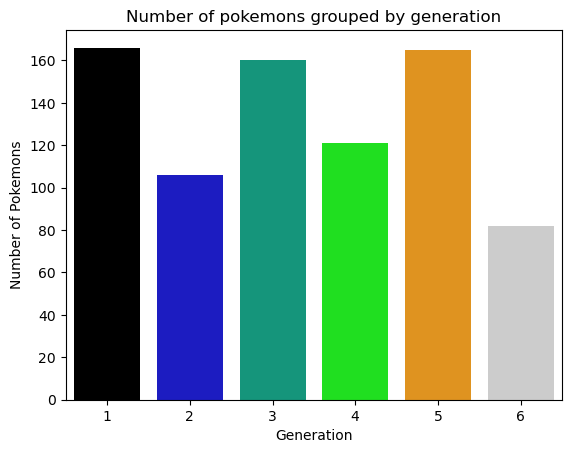

In [20]:
sns.countplot(
    x='Generation',
    data=pokemons,
    hue='Generation',
    palette='nipy_spectral',
    legend=False
)

plt.title('Number of pokemons grouped by generation')
plt.xlabel('Generation')
plt.ylabel('Number of Pokemons')
plt.show()

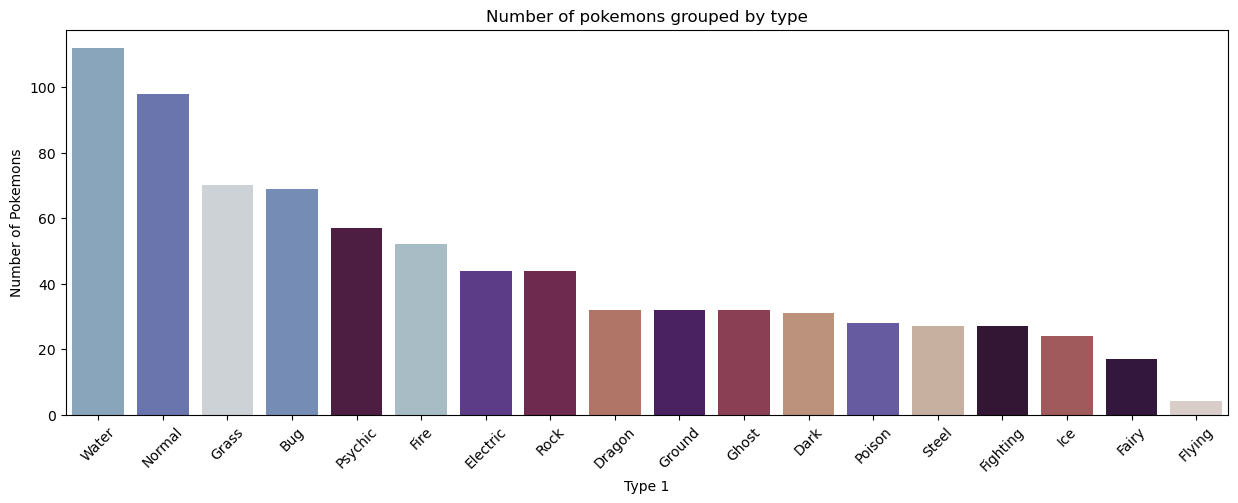

In [21]:
plt.figure(figsize=(15,5))

sns.countplot(
    x='Type 1',
    data=pokemons,
    hue='Type 1',
    palette='twilight',
    order=pokemons['Type 1'].value_counts().index,
    legend=False
)

plt.title('Number of pokemons grouped by type')
plt.xlabel('Type 1')
plt.ylabel('Number of Pokemons')
plt.xticks(rotation=45)
plt.show()

NOTA: Debido a que la cantidad de Pokémon de tipo Agua y Normal es alta en comparación con los demás, ¡los Pokémon correspondientes siempre tendrán estadísticas totales más altas!

Text(0.5, 1.0, 'Boxplots for stats')

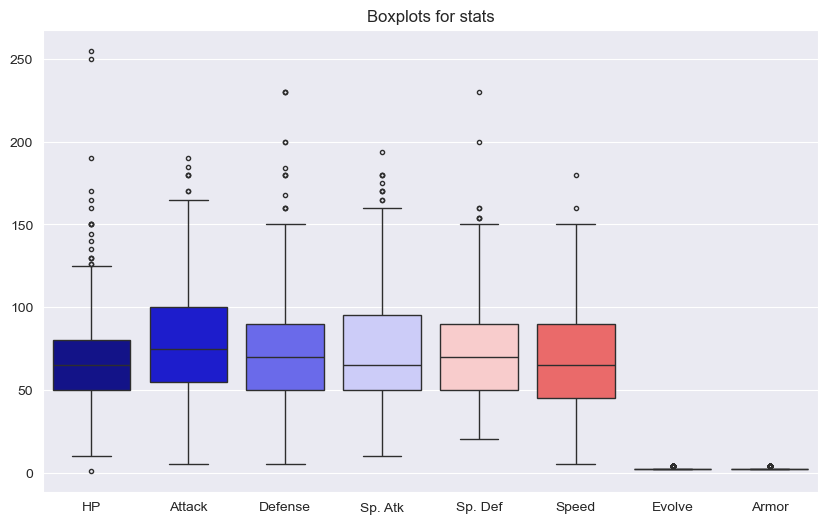

In [22]:
sns.set_style('darkgrid')
plt.figure(figsize=(10,6))
sns.boxplot(data=pokemons.drop(['#','Total','Generation','Legendary'],axis=1),fliersize=3,palette='seismic')
plt.title('Boxplots for stats')

Text(0.5, 1.0, 'Violinplots for stats')

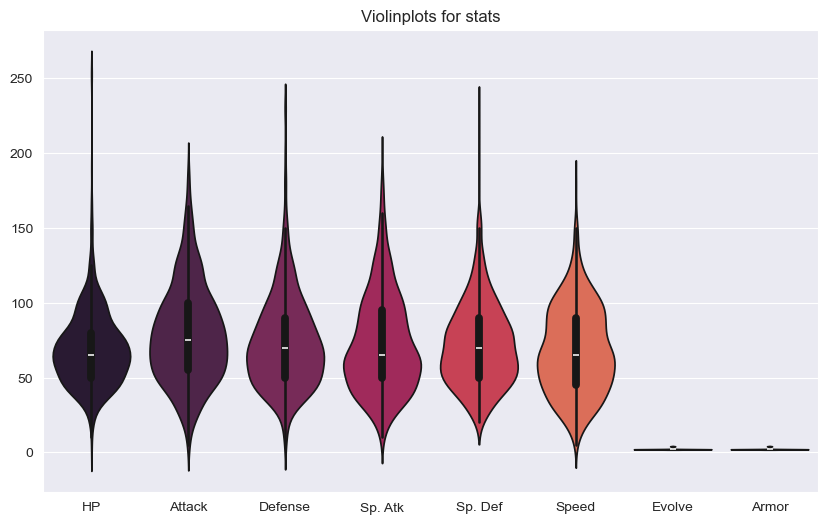

In [23]:
plt.figure(figsize=(10,6))
sns.violinplot(data=pokemons.drop(['#','Total','Generation','Legendary'],axis=1),palette='rocket')
plt.title('Violinplots for stats')

In [24]:
pokemons.groupby('Type 1').sum(numeric_only=True)

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Evolve,Armor
Type 1,,,,,,,,,,,,
Bug,23080,26146,3925,4897,4880,3717,4471,4256,222,0,146,146
Dark,14302,13818,2071,2740,2177,2314,2155,2361,125,2,68,68
Dragon,15180,17617,2666,3588,2764,3099,2843,2657,124,12,76,76
Electric,15994,19510,2631,3040,2917,3961,3243,3718,144,4,92,92
Fairy,7642,7024,1260,1046,1117,1335,1440,826,70,1,34,34
Fighting,9824,11244,1886,2613,1780,1434,1747,1784,91,0,58,58
Fire,17025,23820,3635,4408,3524,4627,3755,3871,167,5,112,112
Flying,2711,1940,283,315,265,377,290,410,22,2,8,8
Ghost,15568,14066,2062,2361,2598,2539,2447,2059,134,2,68,68


In [25]:
pokemons.groupby('Type 1').sum(numeric_only=True).HP
# In this series the types are alphabetically ordered.

Type 1
Bug         3925
Dark        2071
Dragon      2666
Electric    2631
Fairy       1260
Fighting    1886
Fire        3635
Flying       283
Ghost       2062
Grass       4709
Ground      2361
Ice         1728
Normal      7573
Poison      1883
Psychic     4026
Rock        2876
Steel       1761
Water       8071
Name: HP, dtype: int64

In [26]:
pokemons['Type 1'].unique()

array(['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Poison', 'Electric',
       'Ground', 'Fairy', 'Fighting', 'Psychic', 'Rock', 'Ghost', 'Ice',
       'Dragon', 'Dark', 'Steel', 'Flying'], dtype=object)

list_types=pokemons['Type 1'].unique().tolist() #Convierte el arreglo de tipos en una lista para aplicar ordenamiento
list_types.sort() #Ordena los elementos de forma ascendente por defecto
list_types

22. Calculando los datos para la graficación del total de estadísticas por cada tipo de Pokemon, respetando el orden alfabético previamente definido.

22. Calcilando los datos para graficación del total de estadísticas por cada tipo de Pokemon, respetando el orden alfabético previamente definido.

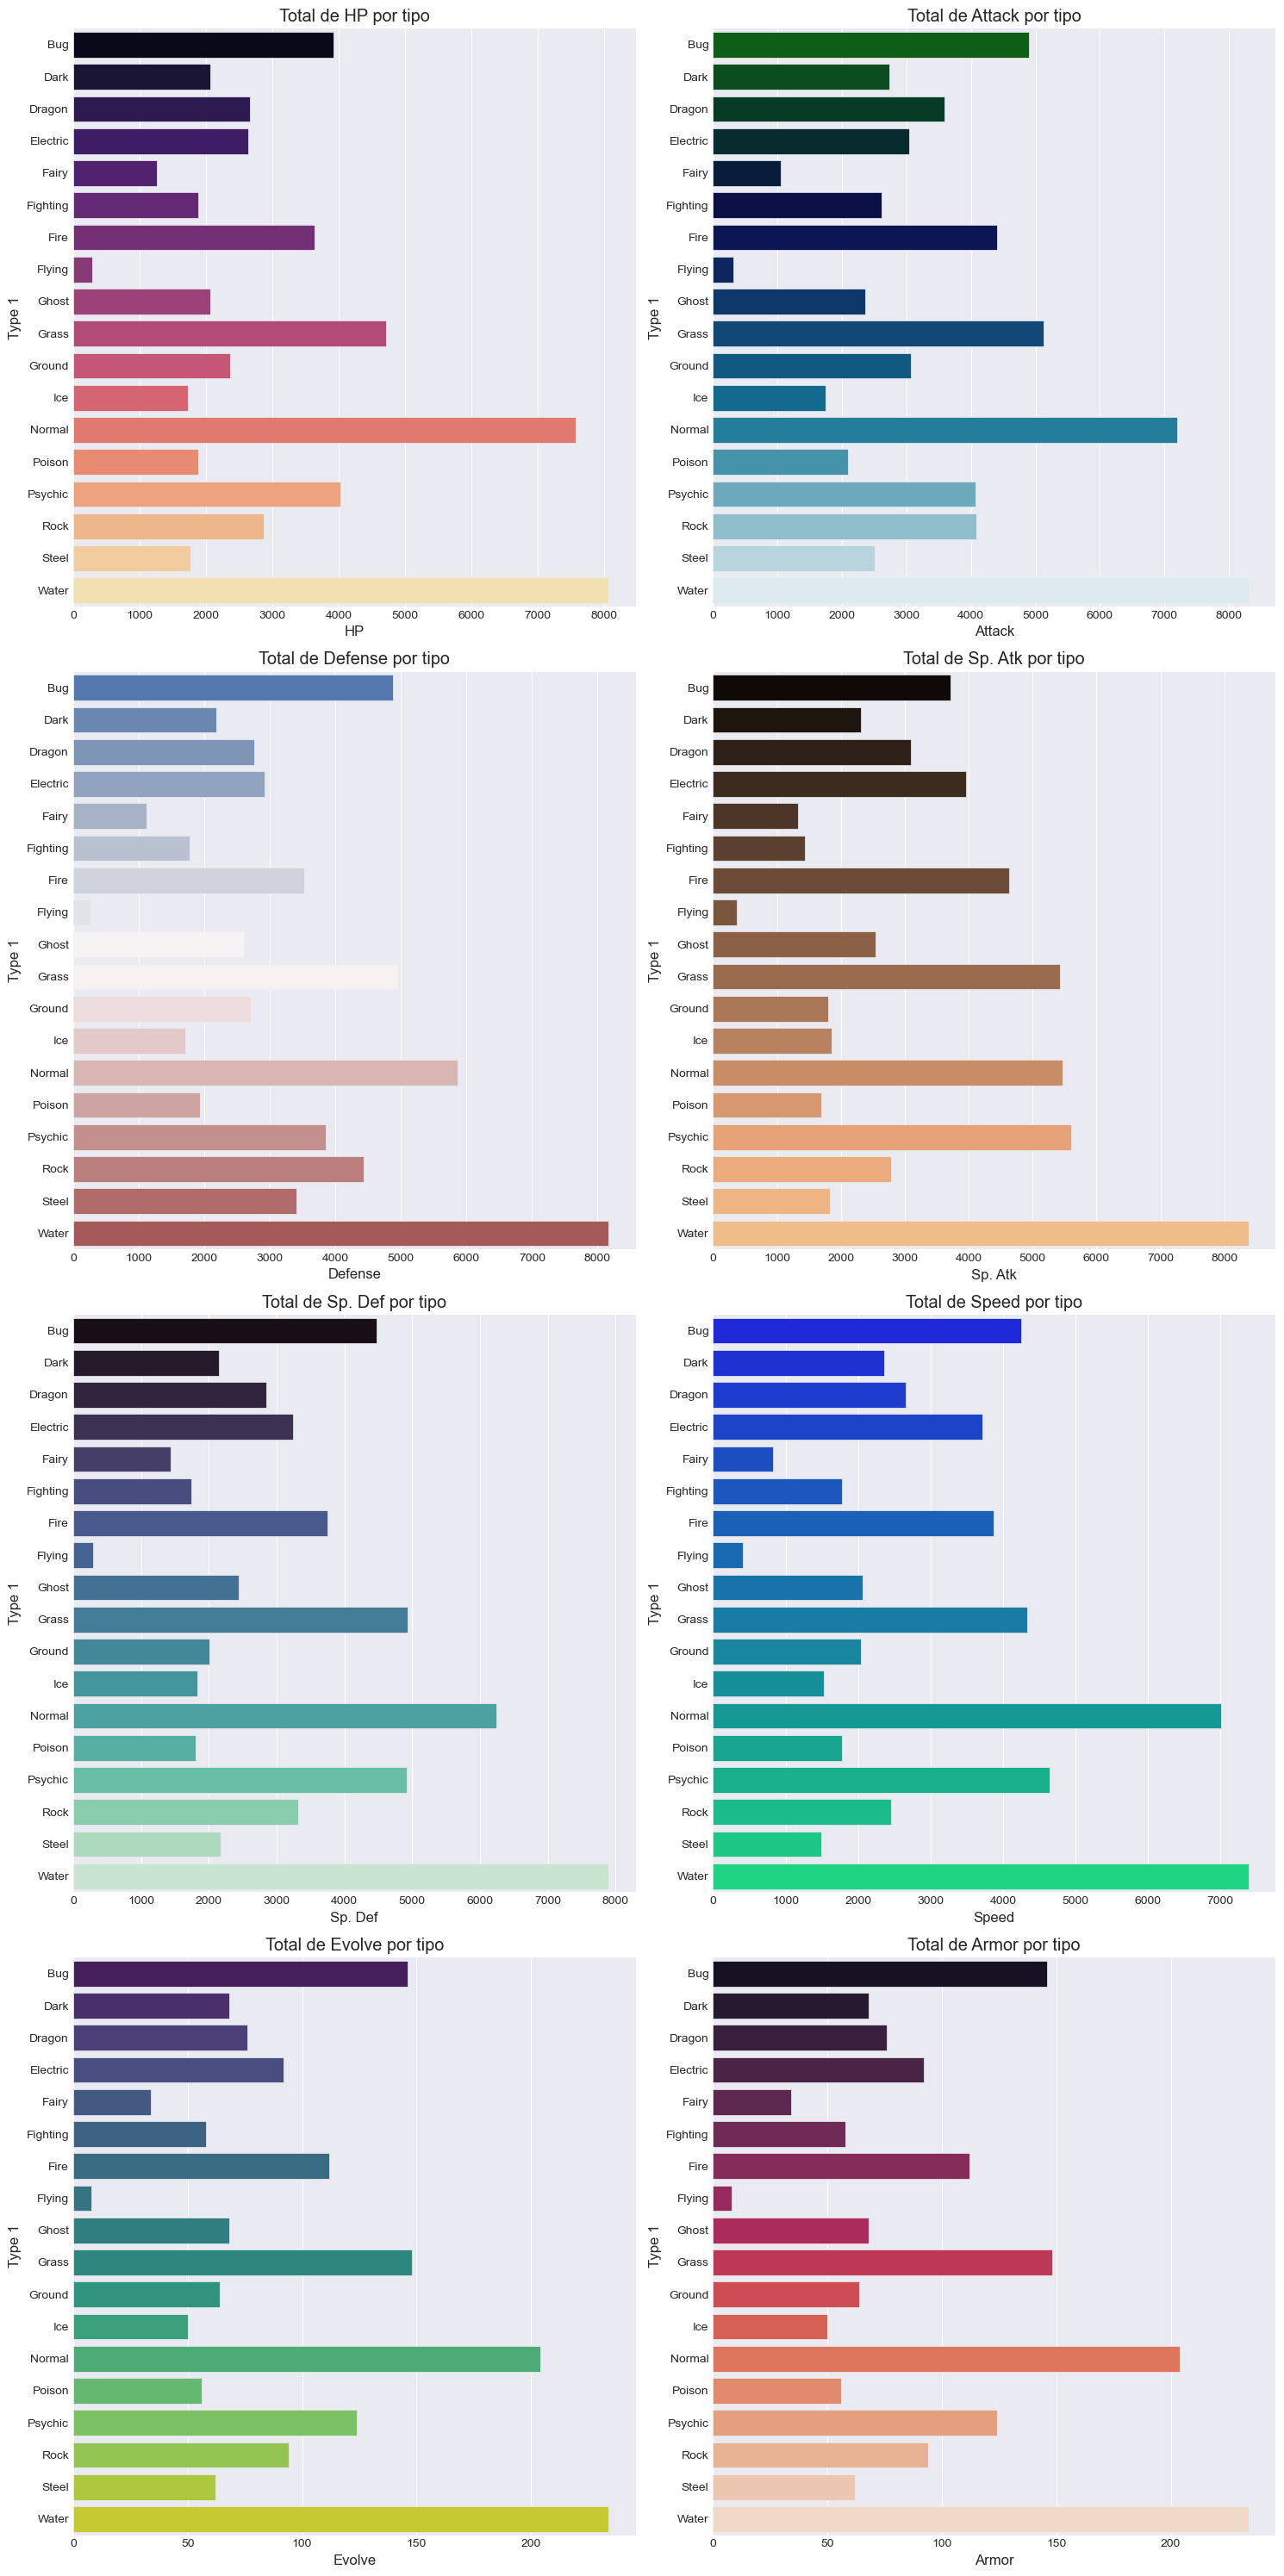

In [27]:
plt.style.use('ggplot')
plt.style.use('seaborn-v0_8-darkgrid')

# Las columnas Evolve y Armor ya existen gracias a las celdas iniciales.
stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Evolve', 'Armor']
pokemon_stats = pokemons.groupby('Type 1')[stats].sum()

palettes = ['magma', 'ocean', 'vlag', 'copper', 'mako', 'winter', 'viridis', 'rocket']

plt.figure(figsize=(15, 30))

for k, stat in enumerate(stats, start=1):
    plt.subplot(4, 2, k)

    sns.barplot(
        x=pokemon_stats[stat],
        y=pokemon_stats.index,
        hue=pokemon_stats.index,
        palette=palettes[k-1],
        legend=False
    )

    plt.title(f'Total de {stat} por tipo')
    plt.xlabel(stat)
    plt.ylabel('Type 1')

plt.tight_layout()
plt.show()

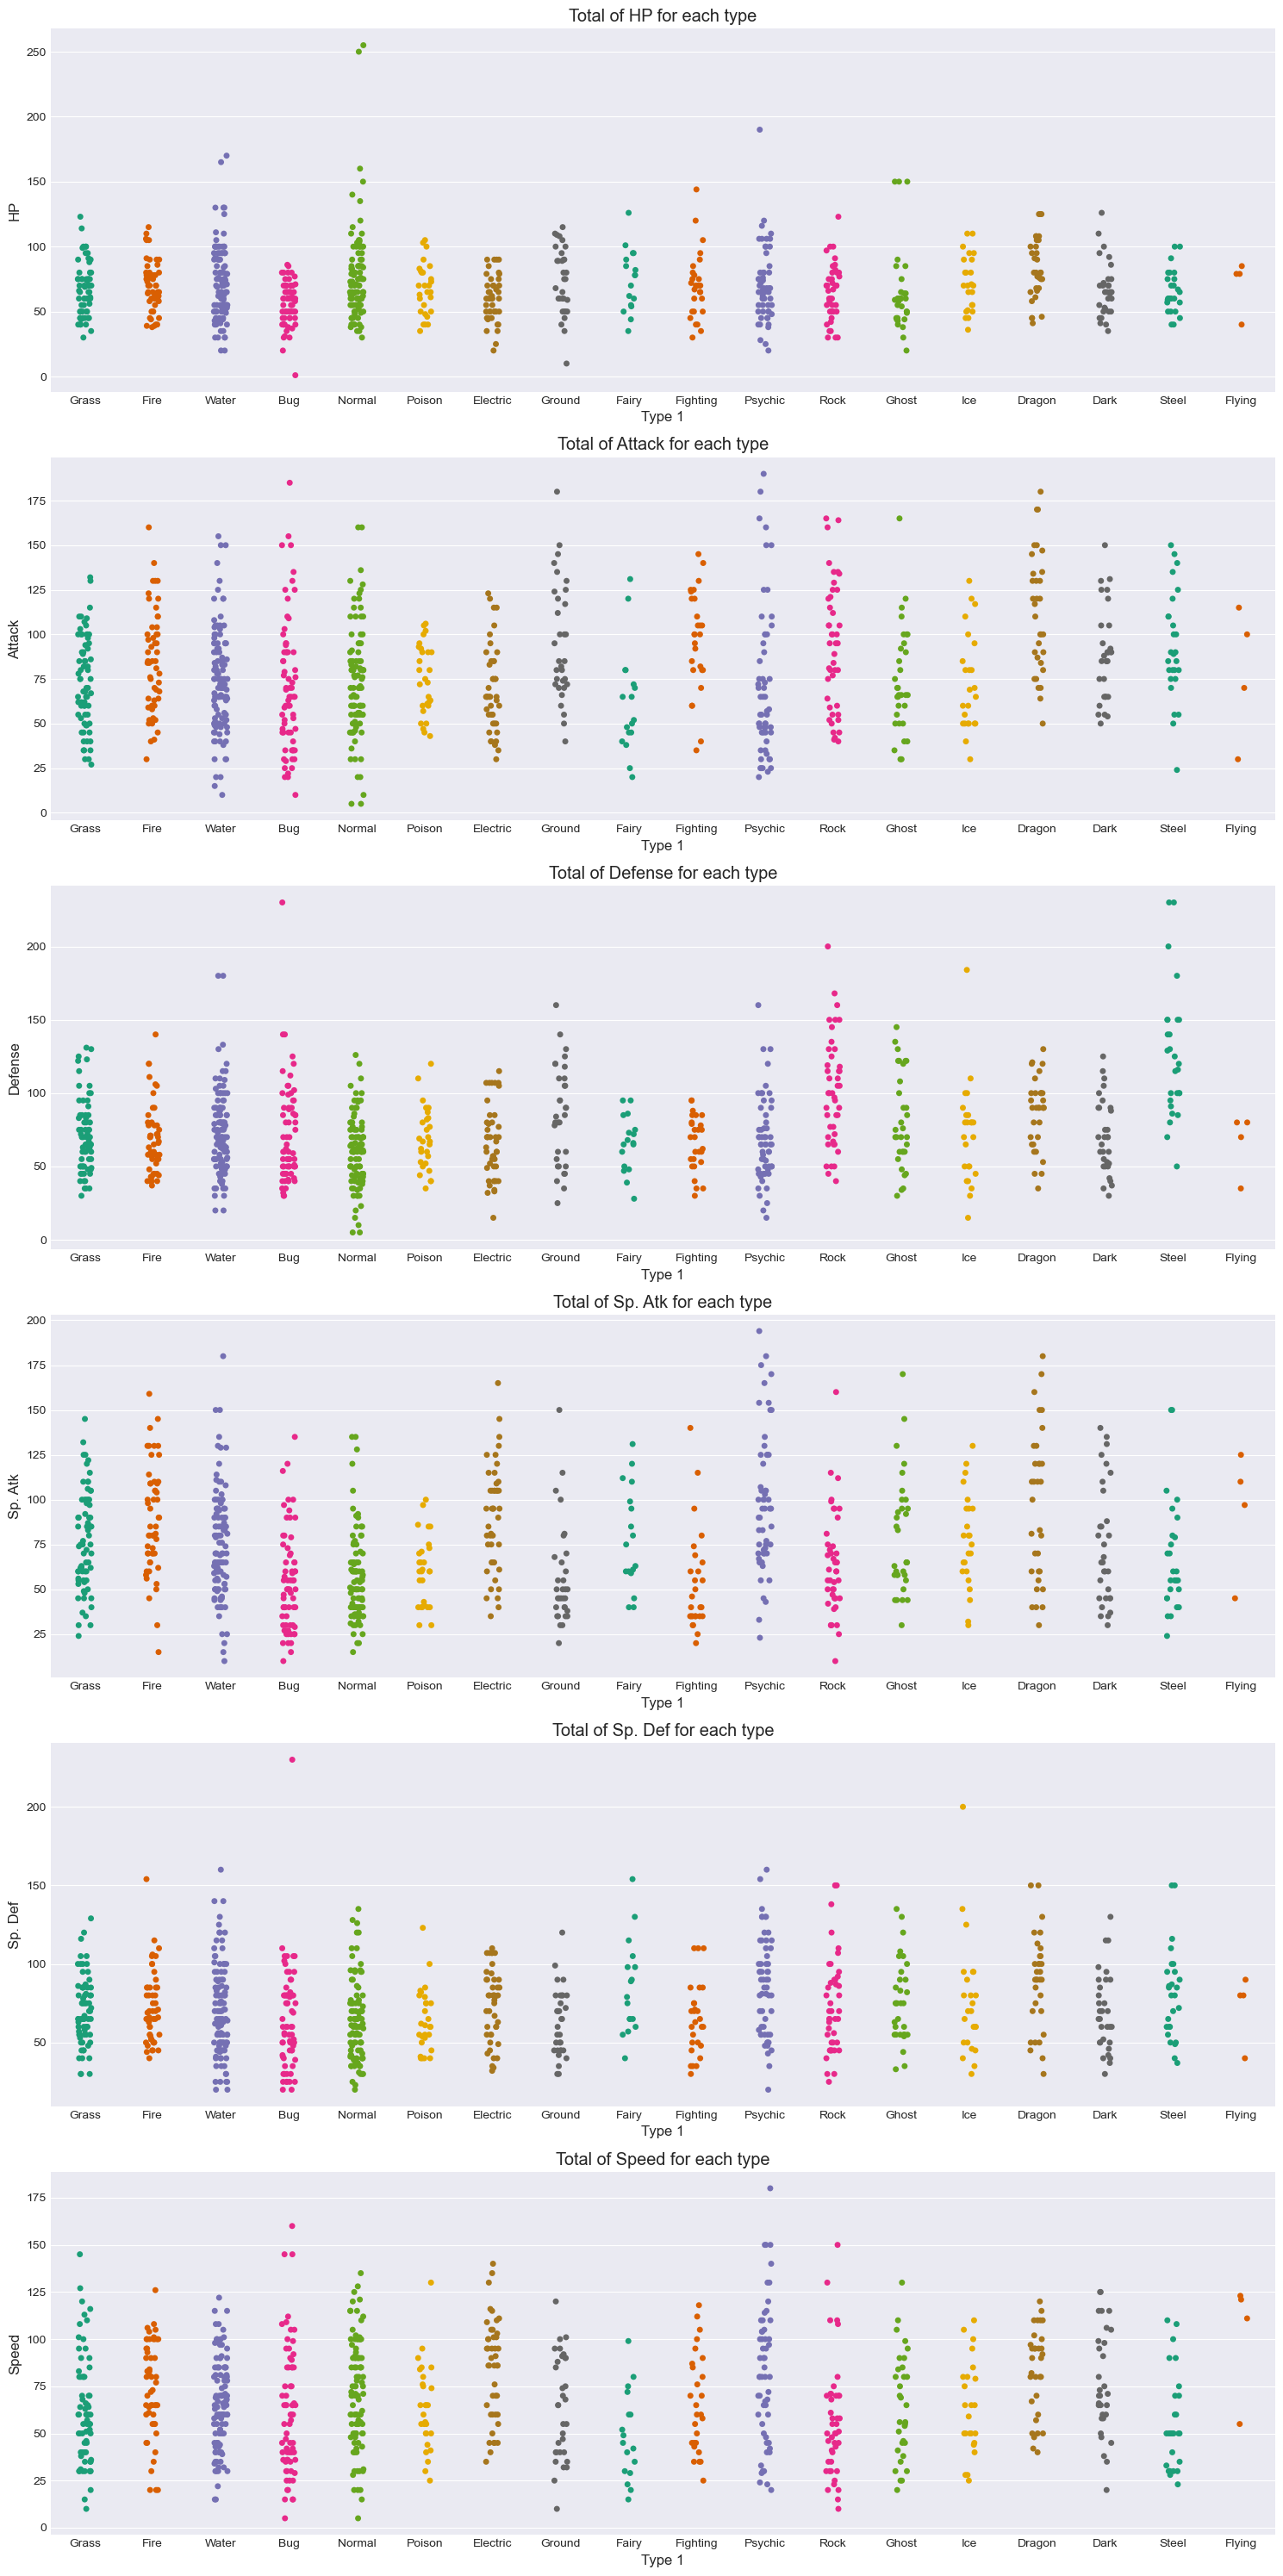

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

stats = pokemons[['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']]

k = 1

plt.figure(figsize=(15,30))

for i in stats:
    plt.subplot(6,1,k)
    k += 1

    sns.stripplot(
        x=pokemons['Type 1'],
        y=pokemons[i],
        hue=pokemons['Type 1'],
        palette='Dark2',
        legend=False
    )

    plt.title(f'Total of {i} for each type')

plt.tight_layout()
plt.show()

In [29]:
list_types = pokemons['Type 1'].unique()
list_types

array(['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Poison', 'Electric',
       'Ground', 'Fairy', 'Fighting', 'Psychic', 'Rock', 'Ghost', 'Ice',
       'Dragon', 'Dark', 'Steel', 'Flying'], dtype=object)

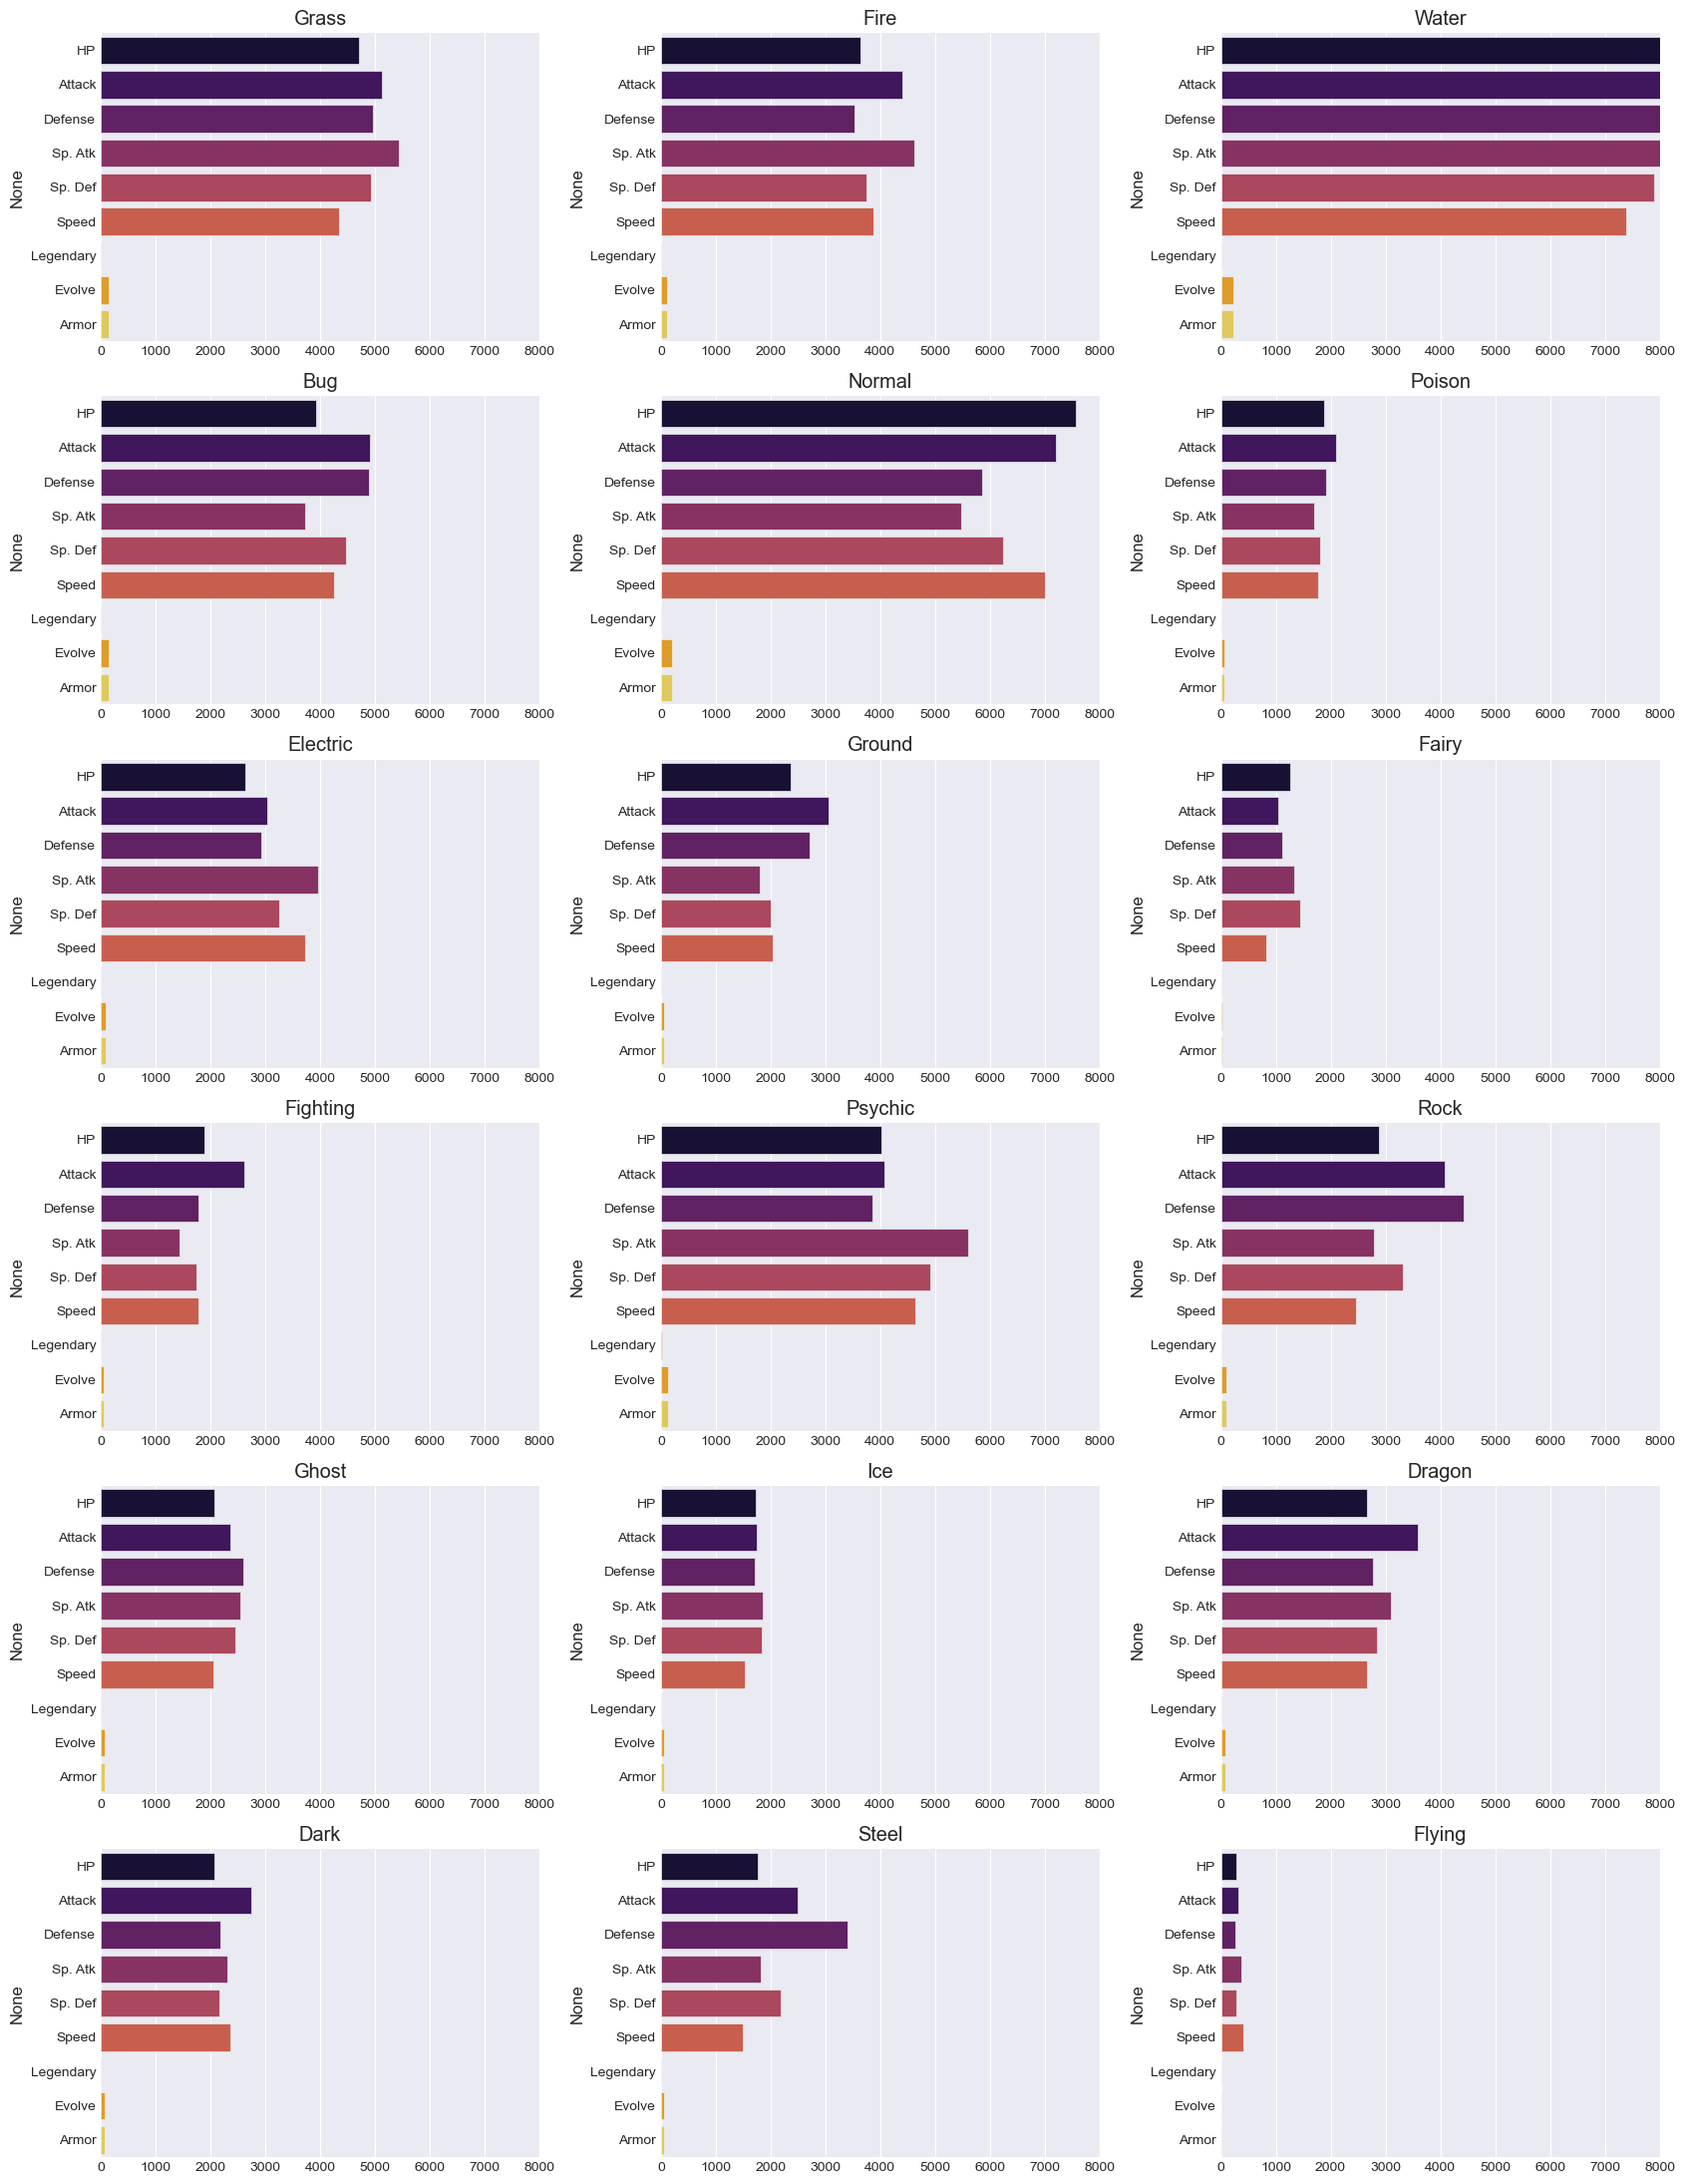

In [30]:
k = 1
plt.figure(figsize=(17, 22))

for i in list_types:
    plt.subplot(6, 3, k)
    k += 1

    data = pokemons[pokemons['Type 1'] == i].sum(numeric_only=True)

    data = data.drop(['#', 'Total', 'Generation'], errors='ignore')

    sns.barplot(
        x=data.values,
        y=data.index,
        hue=data.index,
        palette='inferno',
        legend=False
    )

    plt.title(i)
    plt.xlim(0, 8000)

plt.tight_layout()
plt.show()

Podemos observar que los Pokémon de tipo **Normal**, **Bug** y **Water** tienen más observaciones que el resto.

Pero, ¿qué pasa si calculamos el promedio de cada estadística y lo graficamos?  
En este caso, el número pequeño de algunos Pokémon de diferentes tipos no afectará el análisis.

Primero, vamos a calcular el promedio de las estadísticas agrupadas por el tipo de Pokémon.

Después, se crea un DataFrame con todos los promedios agrupados por tipo de Pokémon.

In [31]:
stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

df = pd.DataFrame()

for i in stats:
    df[i] = pokemons.groupby('Type 1')[i].describe()['mean']

df

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
Type 1,,,,,,
Bug,56.884058,70.971014,70.724638,53.869565,64.797101,61.681159
Dark,66.806452,88.387097,70.225806,74.645161,69.516129,76.161290
Dragon,83.312500,112.125000,86.375000,96.843750,88.843750,83.031250
Electric,59.795455,69.090909,66.295455,90.022727,73.704545,84.500000
Fairy,74.117647,61.529412,65.705882,78.529412,84.705882,48.588235
Fighting,69.851852,96.777778,65.925926,53.111111,64.703704,66.074074
Fire,69.903846,84.769231,67.769231,88.980769,72.211538,74.442308
Flying,70.750000,78.750000,66.250000,94.250000,72.500000,102.500000
Ghost,64.437500,73.781250,81.187500,79.343750,76.468750,64.343750


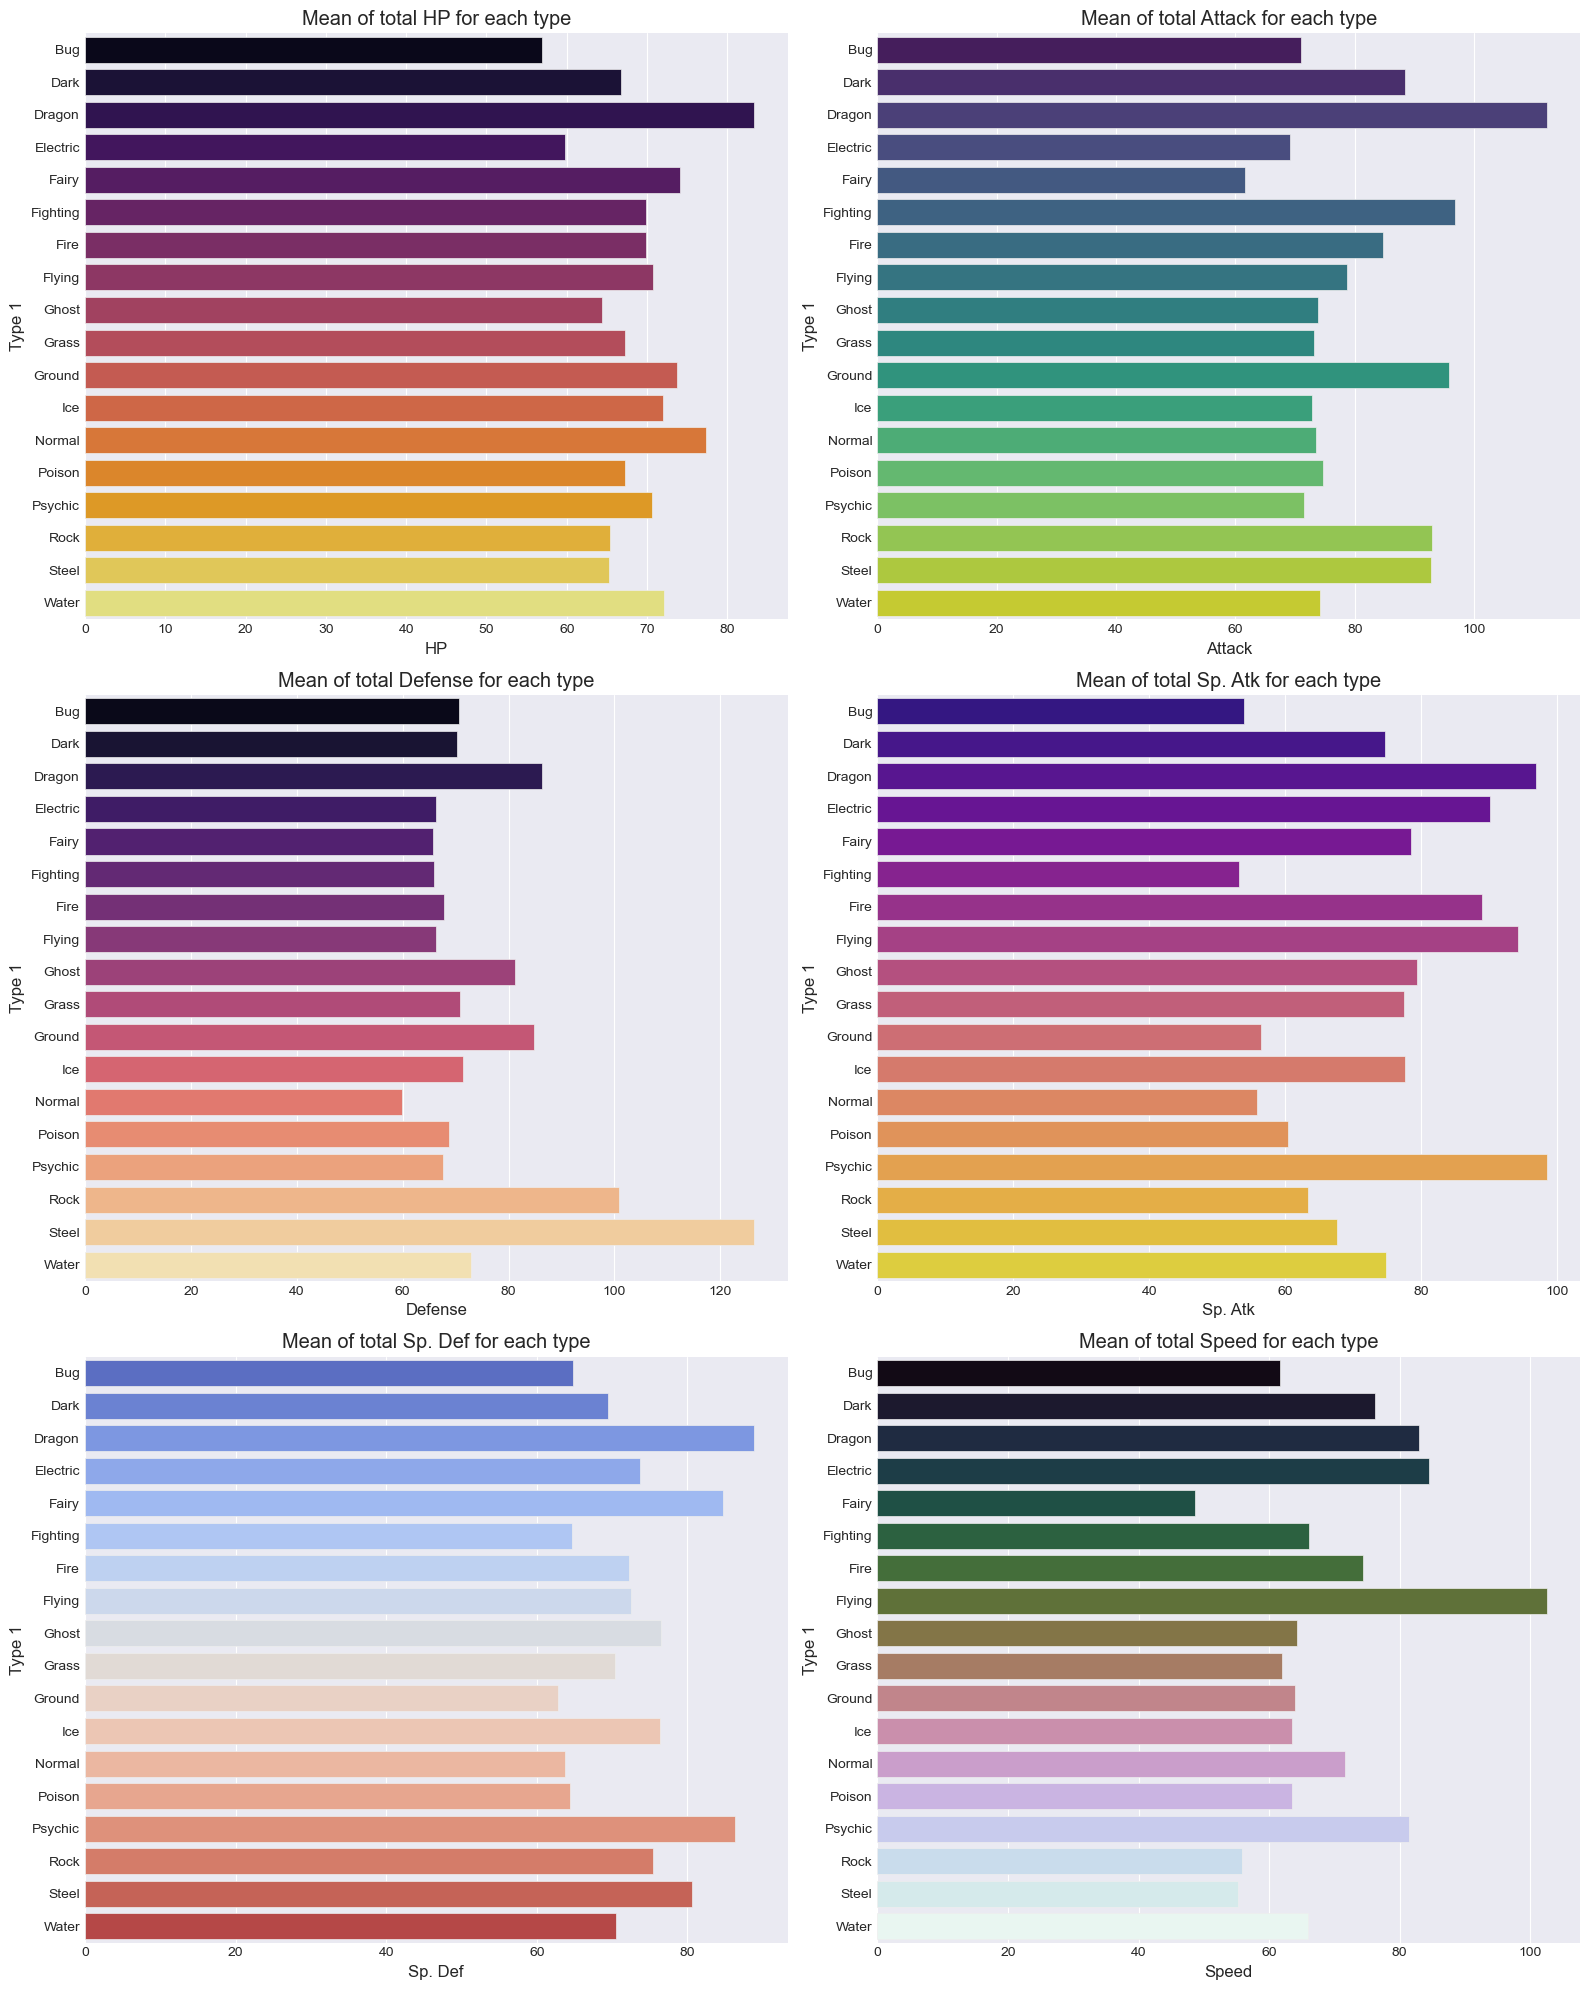

In [32]:
palette = ['inferno', 'viridis', 'magma', 'plasma', 'coolwarm', 'cubehelix']

plt.figure(figsize=(16,20))

k=1

m=0

for i in stats:
    plt.subplot(3,2,k)
    k=k+1
    sns.barplot(x=df[i], y=df.index, hue=df.index, palette=palette[m], legend=False)
    m=m+1
    plt.title(str('Mean of total ') + i + str(' for each type'))
    plt.xlabel(i)

plt.tight_layout()
plt.show()

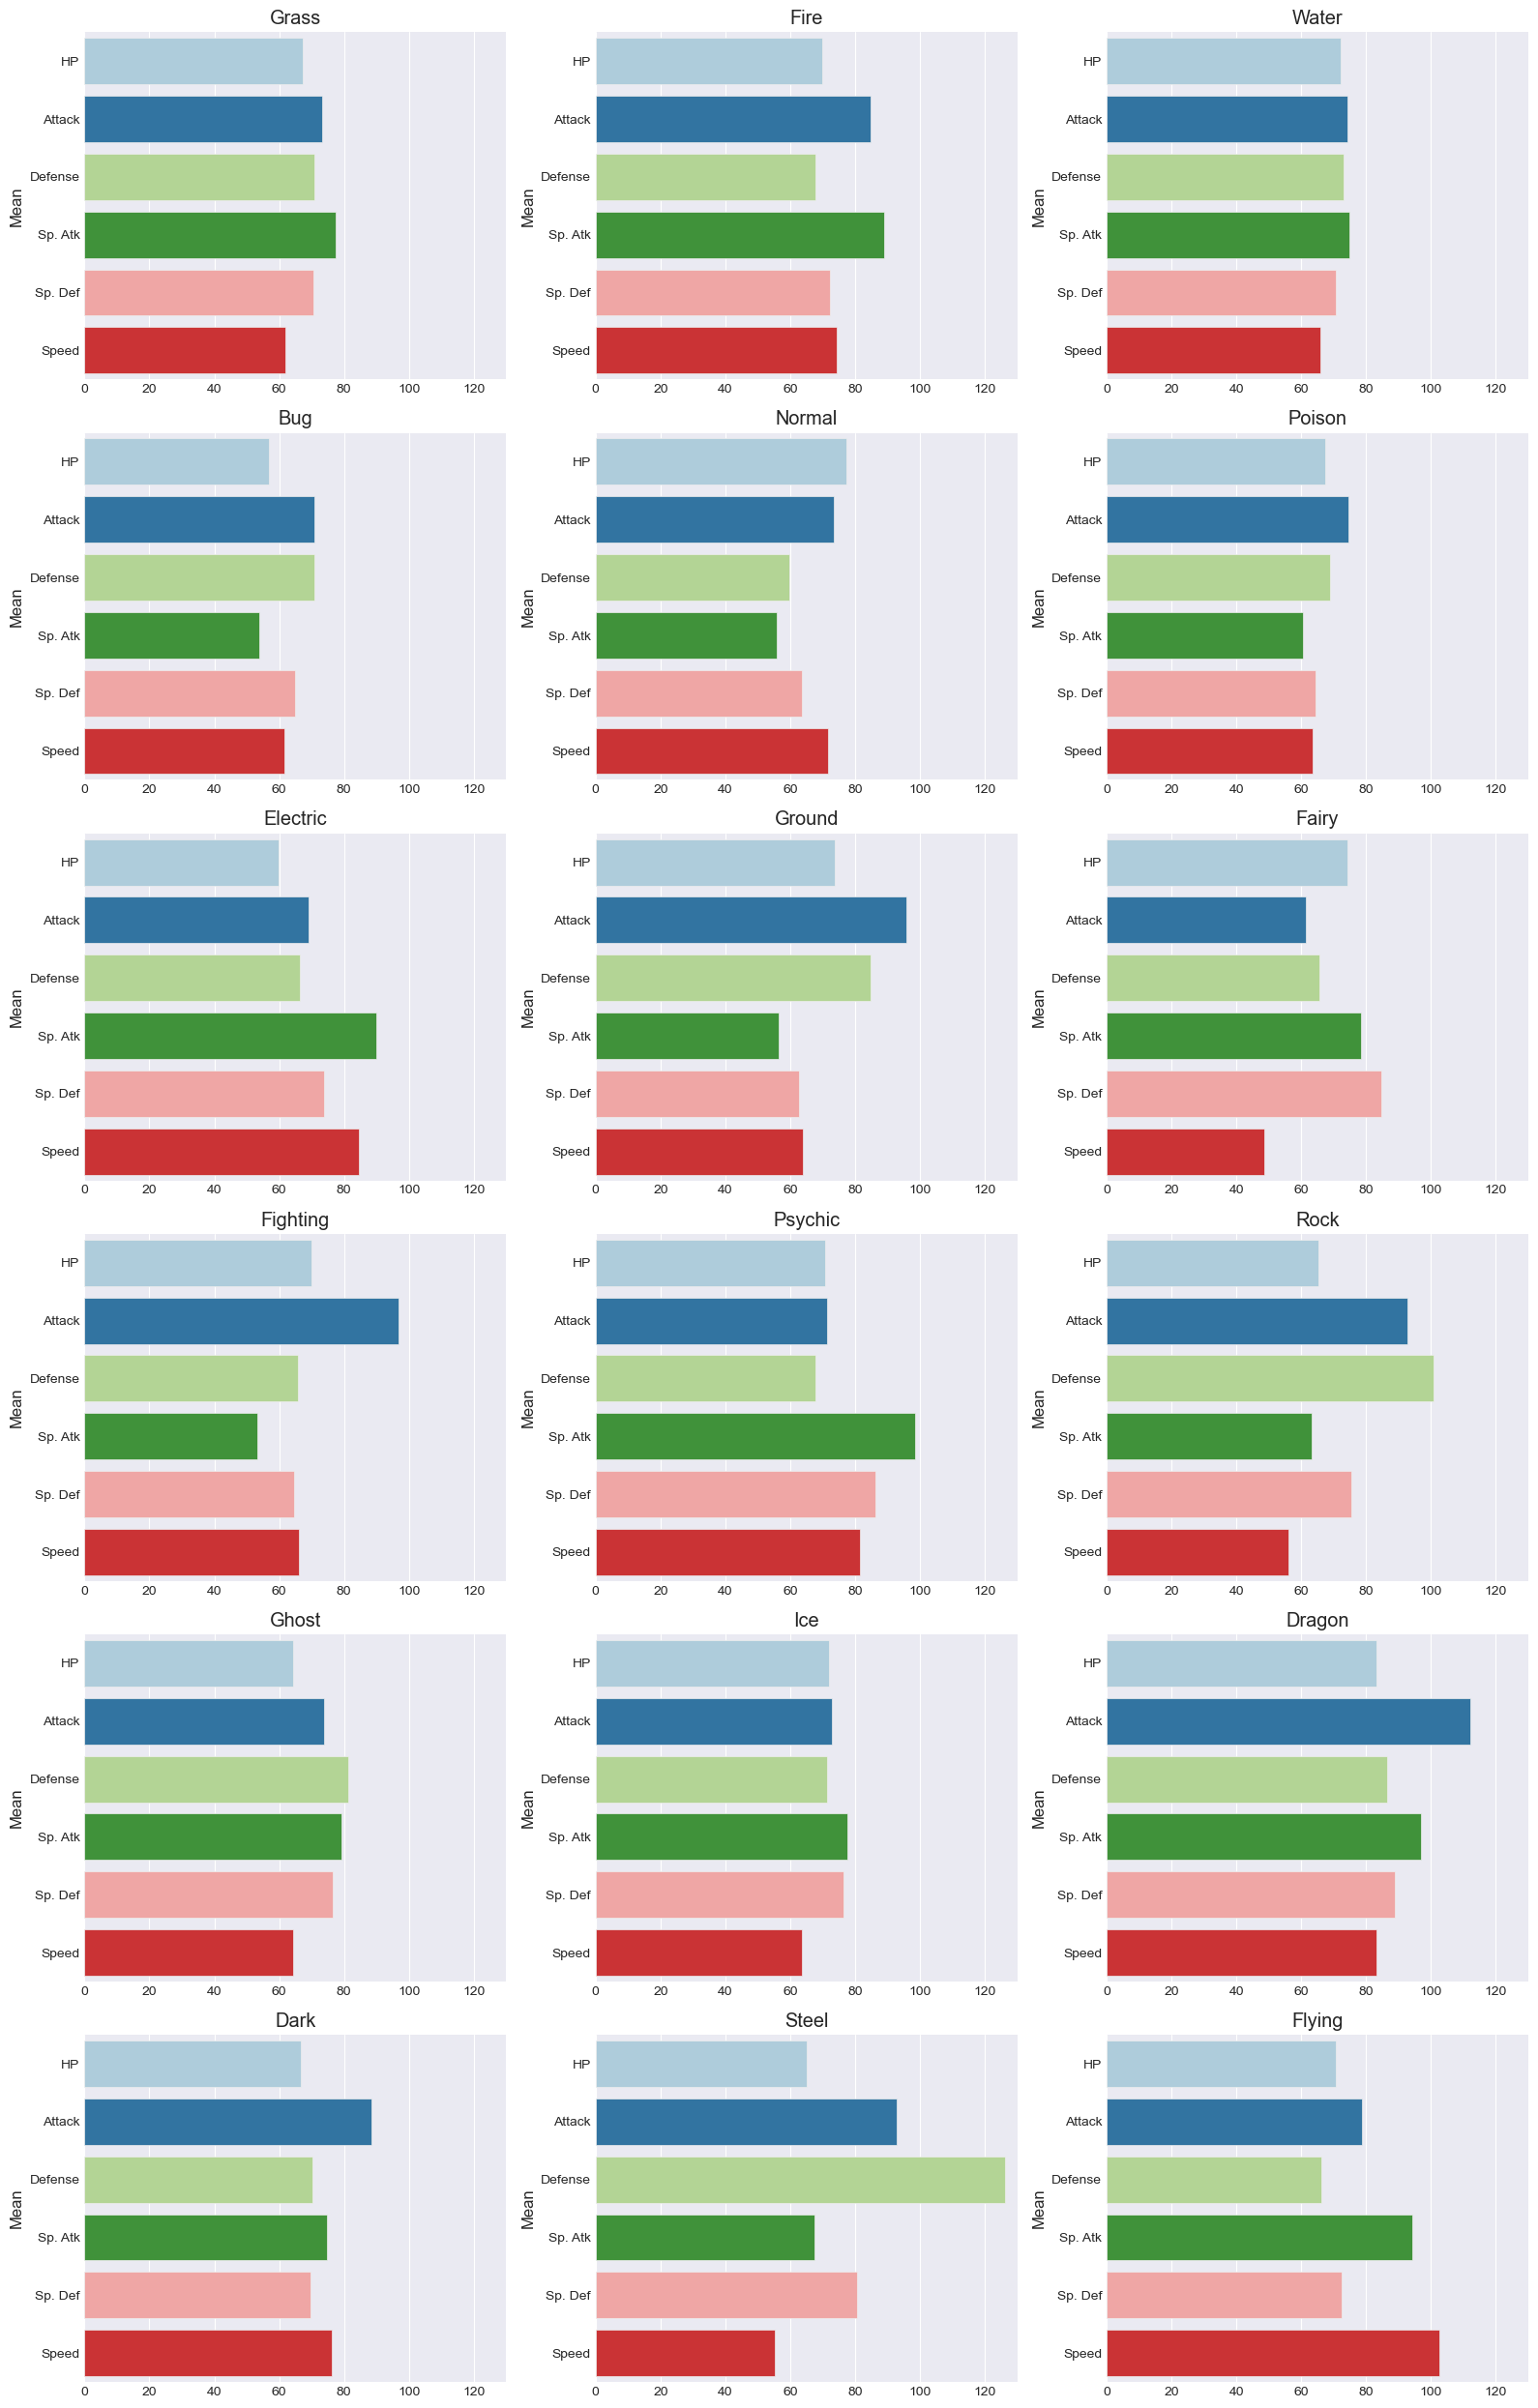

In [33]:
k=1

plt.figure(figsize=(16,25))

for i in list_types:
    plt.subplot(6,3,k)
    k=k+1

    sns.barplot(
        x=df.loc[i,:].values,
        y=df.loc[i,:].index,
        hue=df.loc[i,:].index,
        palette='Paired',
        legend=False
    )

    plt.title(i)
    plt.xlim(0,130)
    plt.ylabel('Mean')

plt.tight_layout()
plt.show()

Ahora vamos a comparar las estadísticas totales iniciales con el promedio de las estadísticas totales.

Primero se muestra la suma total de las estadísticas agrupadas por tipo de Pokémon.
Esto permite observar qué tipos tienen mayor acumulación de estadísticas en general.

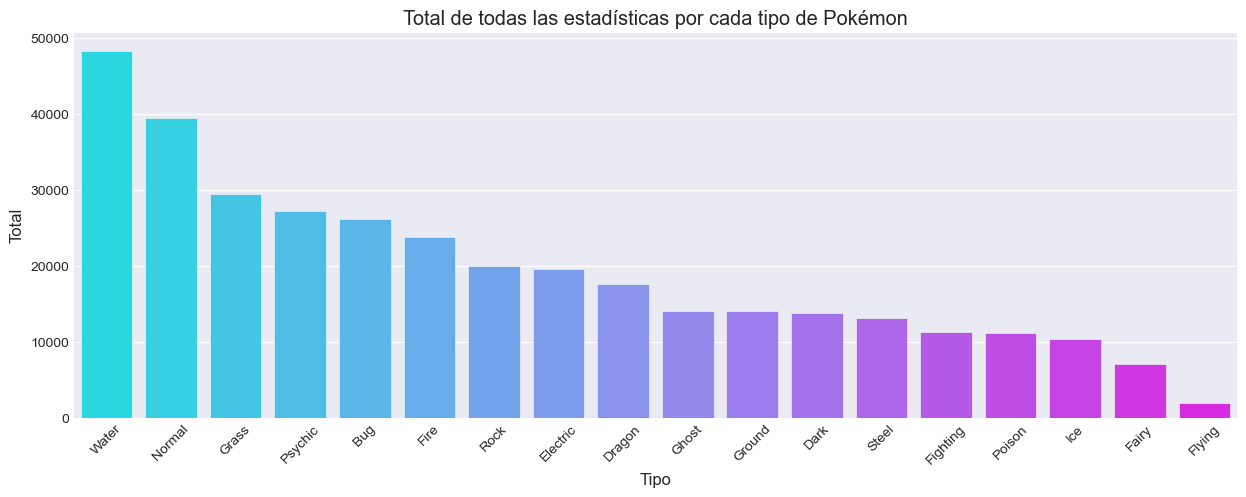

In [34]:
plt.figure(figsize=(15, 5))

sns.barplot(
    x=pokemons.groupby('Type 1').sum(numeric_only=True).Total.sort_values(ascending=False).index,
    y=pokemons.groupby('Type 1').sum(numeric_only=True).Total.sort_values(ascending=False).values,
    hue=pokemons.groupby('Type 1').sum(numeric_only=True).Total.sort_values(ascending=False).index,
    palette='cool',
    legend=False
)

plt.title('Total de todas las estadísticas por cada tipo de Pokémon')
plt.xlabel('Tipo')
plt.ylabel('Total')
plt.xticks(rotation=45)

plt.show()

### 3 tipos principales de Pokémon con base en el total inicial:

1. Water  
2. Normal  
3. Grass

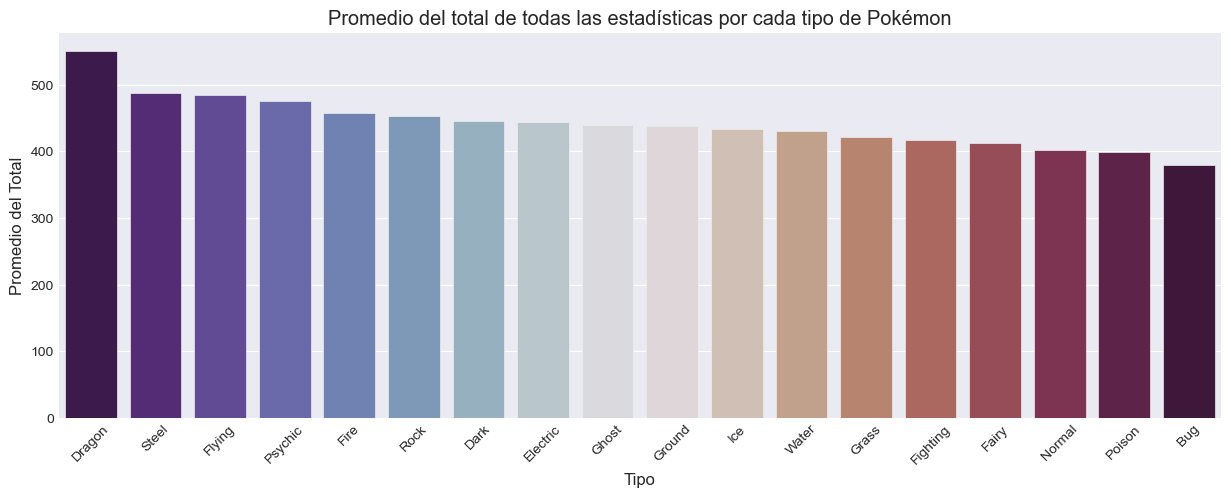

In [35]:
plt.figure(figsize=(15,5))

sns.barplot(
    x=pokemons.groupby('Type 1').mean(numeric_only=True).Total.sort_values(ascending=False).index,
    y=pokemons.groupby('Type 1').mean(numeric_only=True).Total.sort_values(ascending=False).values,
    hue=pokemons.groupby('Type 1').mean(numeric_only=True).Total.sort_values(ascending=False).index,
    palette='twilight_shifted',
    legend=False
)

plt.title('Promedio del total de todas las estadísticas por cada tipo de Pokémon')
plt.xlabel('Tipo')
plt.ylabel('Promedio del Total')
plt.xticks(rotation=45)

plt.show()

## 32. Mejor estadística promedio para cada tipo de Pokémon

Se identifica la estadística con mayor promedio dentro de cada tipo. Para esta práctica se incluye la columna de evolución disponible en el dataset (`Armor` o `Evolve`).

In [36]:
# Definición consistente de las columnas utilizadas en los análisis posteriores.
type_col = 'Type 1'
evolution_col = 'Armor' if 'Armor' in pokemons.columns else 'Evolve'

stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', evolution_col]
list_types = sorted(pokemons[type_col].dropna().unique().tolist())

df = pokemons.groupby(type_col)[stats].mean()
df

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Armor
Type 1,,,,,,,
Bug,56.884058,70.971014,70.724638,53.869565,64.797101,61.681159,2.115942
Dark,66.806452,88.387097,70.225806,74.645161,69.516129,76.161290,2.193548
Dragon,83.312500,112.125000,86.375000,96.843750,88.843750,83.031250,2.375000
Electric,59.795455,69.090909,66.295455,90.022727,73.704545,84.500000,2.090909
Fairy,74.117647,61.529412,65.705882,78.529412,84.705882,48.588235,2.000000
Fighting,69.851852,96.777778,65.925926,53.111111,64.703704,66.074074,2.148148
Fire,69.903846,84.769231,67.769231,88.980769,72.211538,74.442308,2.153846
Flying,70.750000,78.750000,66.250000,94.250000,72.500000,102.500000,2.000000
Ghost,64.437500,73.781250,81.187500,79.343750,76.468750,64.343750,2.125000


In [37]:
best_stats = df.idxmax(axis=1)

for pokemon_type, best_stat in best_stats.items():
    print(f'La mejor estadística promedio del tipo {pokemon_type} es: {best_stat}')

La mejor estadística promedio del tipo Bug es: Attack
La mejor estadística promedio del tipo Dark es: Attack
La mejor estadística promedio del tipo Dragon es: Attack
La mejor estadística promedio del tipo Electric es: Sp. Atk
La mejor estadística promedio del tipo Fairy es: Sp. Def
La mejor estadística promedio del tipo Fighting es: Attack
La mejor estadística promedio del tipo Fire es: Sp. Atk
La mejor estadística promedio del tipo Flying es: Speed
La mejor estadística promedio del tipo Ghost es: Defense
La mejor estadística promedio del tipo Grass es: Sp. Atk
La mejor estadística promedio del tipo Ground es: Attack
La mejor estadística promedio del tipo Ice es: Sp. Atk
La mejor estadística promedio del tipo Normal es: HP
La mejor estadística promedio del tipo Poison es: Attack
La mejor estadística promedio del tipo Psychic es: Sp. Atk
La mejor estadística promedio del tipo Rock es: Defense
La mejor estadística promedio del tipo Steel es: Defense
La mejor estadística promedio del tipo

## 33. Pokémon con evolución avanzada

Se muestran los Pokémon con el nivel de evolución más alto registrado en el dataset. Este filtro permite identificar las formas especiales o evolucionadas.

In [38]:
max_evolution = pokemons[evolution_col].max()
pokemons[pokemons[evolution_col] == max_evolution].sort_values('Name')

,#,Name,Type 1,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Evolve,Armor
511,460,AbomasnowMega Abomasnow,Grass,594,90,132,105,132,105,30,4,False,4,4
393,359,AbsolMega Absol,Dark,565,65,150,60,115,60,115,3,False,4,4
154,142,AerodactylMega Aerodactyl,Rock,615,80,135,85,70,95,150,1,False,4,4
333,306,AggronMega Aggron,Steel,630,70,140,230,60,80,50,3,False,4,4
71,65,AlakazamMega Alakazam,Psychic,590,55,50,65,175,95,150,1,False,4,4
366,334,AltariaMega Altaria,Dragon,590,75,110,110,110,105,80,3,False,4,4
196,181,AmpharosMega Ampharos,Electric,610,90,95,105,165,110,45,2,False,4,4
591,531,AudinoMega Audino,Normal,545,103,60,126,80,126,50,5,False,4,4
387,354,BanetteMega Banette,Ghost,555,64,165,75,93,83,75,3,False,4,4
19,15,BeedrillMega Beedrill,Bug,495,65,150,40,15,80,145,1,False,4,4


## 34. Corrección de nombres de Pokémon Mega

Algunos registros pueden contener nombres repetidos alrededor de la palabra `Mega`. Se genera una versión corregida para visualización sin modificar los demás atributos.

In [39]:
pokemons['Name_Corrected'] = pokemons['Name'].astype(str).str.replace(
    r'^(.*?)Mega\s*\1', 'Mega ', regex=True
).str.replace(r'\s+', ' ', regex=True).str.strip()

pokemons[['Name', 'Name_Corrected']].head()

,Name,Name_Corrected
0,Bulbasaur,Bulbasaur
1,Ivysaur,Ivysaur
2,Venusaur,Venusaur
3,VenusaurMega Venusaur,Mega
4,Charmander,Charmander


## 35. Mejor Pokémon de cada tipo para cada estadística

Para cada tipo se obtiene el Pokémon con el valor más alto en cada estadística numérica.

In [40]:
for pokemon_type in list_types:
    print(f'\nTYPE {pokemon_type.upper()}')
    type_data = pokemons[pokemons[type_col] == pokemon_type]

    for stat in stats:
        best_pokemon = type_data.loc[type_data[stat].idxmax(), 'Name_Corrected']
        print(f'Mejor {stat}: {best_pokemon}')

    print('*' * 45)


TYPE BUG
Mejor HP: Yanmega
Mejor Attack: Mega
Mejor Defense: Shuckle
Mejor Sp. Atk: Volcarona
Mejor Sp. Def: Shuckle
Mejor Speed: Ninjask
Mejor Armor: Mega
*********************************************

TYPE DARK
Mejor HP: Yveltal
Mejor Attack: Mega
Mejor Defense: Mega
Mejor Sp. Atk: Mega
Mejor Sp. Def: Umbreon
Mejor Speed: Weavile
Mejor Armor: Mega
*********************************************

TYPE DRAGON
Mejor HP: Kyurem
Mejor Attack: Mega
Mejor Defense: Mega
Mejor Sp. Atk: Mega
Mejor Sp. Def: Mega
Mejor Speed: Mega
Mejor Armor: Mega
*********************************************

TYPE ELECTRIC
Mejor HP: Zapdos
Mejor Attack: Electivire
Mejor Defense: Magnezone
Mejor Sp. Atk: Mega
Mejor Sp. Def: Mega
Mejor Speed: Electrode
Mejor Armor: Mega
*********************************************

TYPE FAIRY
Mejor HP: Xerneas
Mejor Attack: Xerneas
Mejor Defense: Togekiss
Mejor Sp. Atk: Xerneas
Mejor Sp. Def: Florges
Mejor Speed: Xerneas
Mejor Armor: Clefairy
************************************

## 36. Pokémon agrupados por generación

Se grafica la cantidad de Pokémon que pertenecen a cada generación.

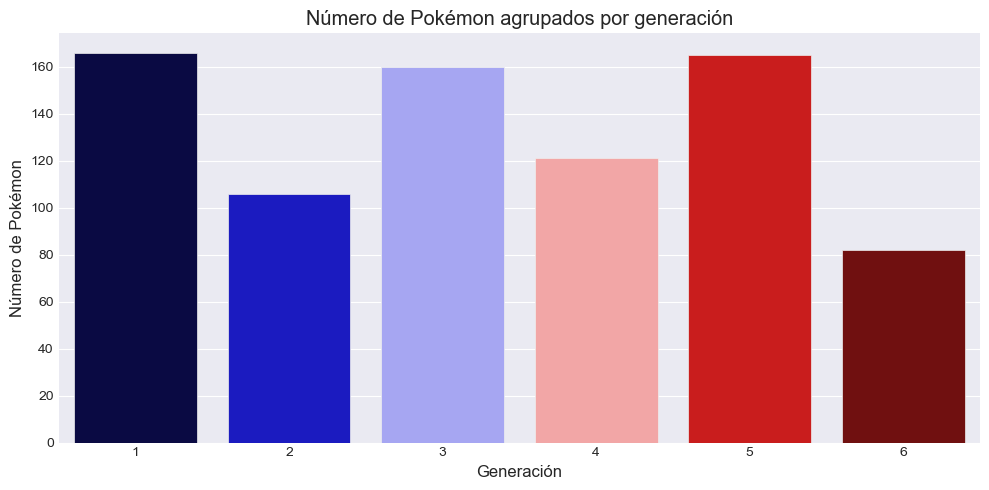

In [41]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=pokemons,
    x='Generation',
    hue='Generation',
    palette='seismic',
    legend=False
)
plt.title('Número de Pokémon agrupados por generación')
plt.xlabel('Generación')
plt.ylabel('Número de Pokémon')
plt.tight_layout()
plt.show()

## 37. Suma de estadísticas de todos los Pokémon por generación

In [42]:
generation_summary = pokemons.groupby('Generation')[
    ['#', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Legendary', evolution_col]
].sum(numeric_only=True)

generation_summary

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,Armor
Generation,,,,,,,,,,
1,12586,70851,10926,12722,11763,11922,11469,12049,6,362
2,21442,44338,7548,7635,7779,6990,7834,6552,5,226
3,51515,69796,10647,13060,11856,12129,11396,10708,18,360
4,53536,55541,8843,10027,9454,9245,9340,8632,13,252
5,94755,71773,11845,13541,11934,11878,11342,11233,15,332
6,56417,35783,5598,6216,6288,6092,6141,5448,8,166


## 38. Estadísticas por generación con gráficos de dispersión

Cada gráfico permite observar la distribución de una estadística dentro de las generaciones disponibles.

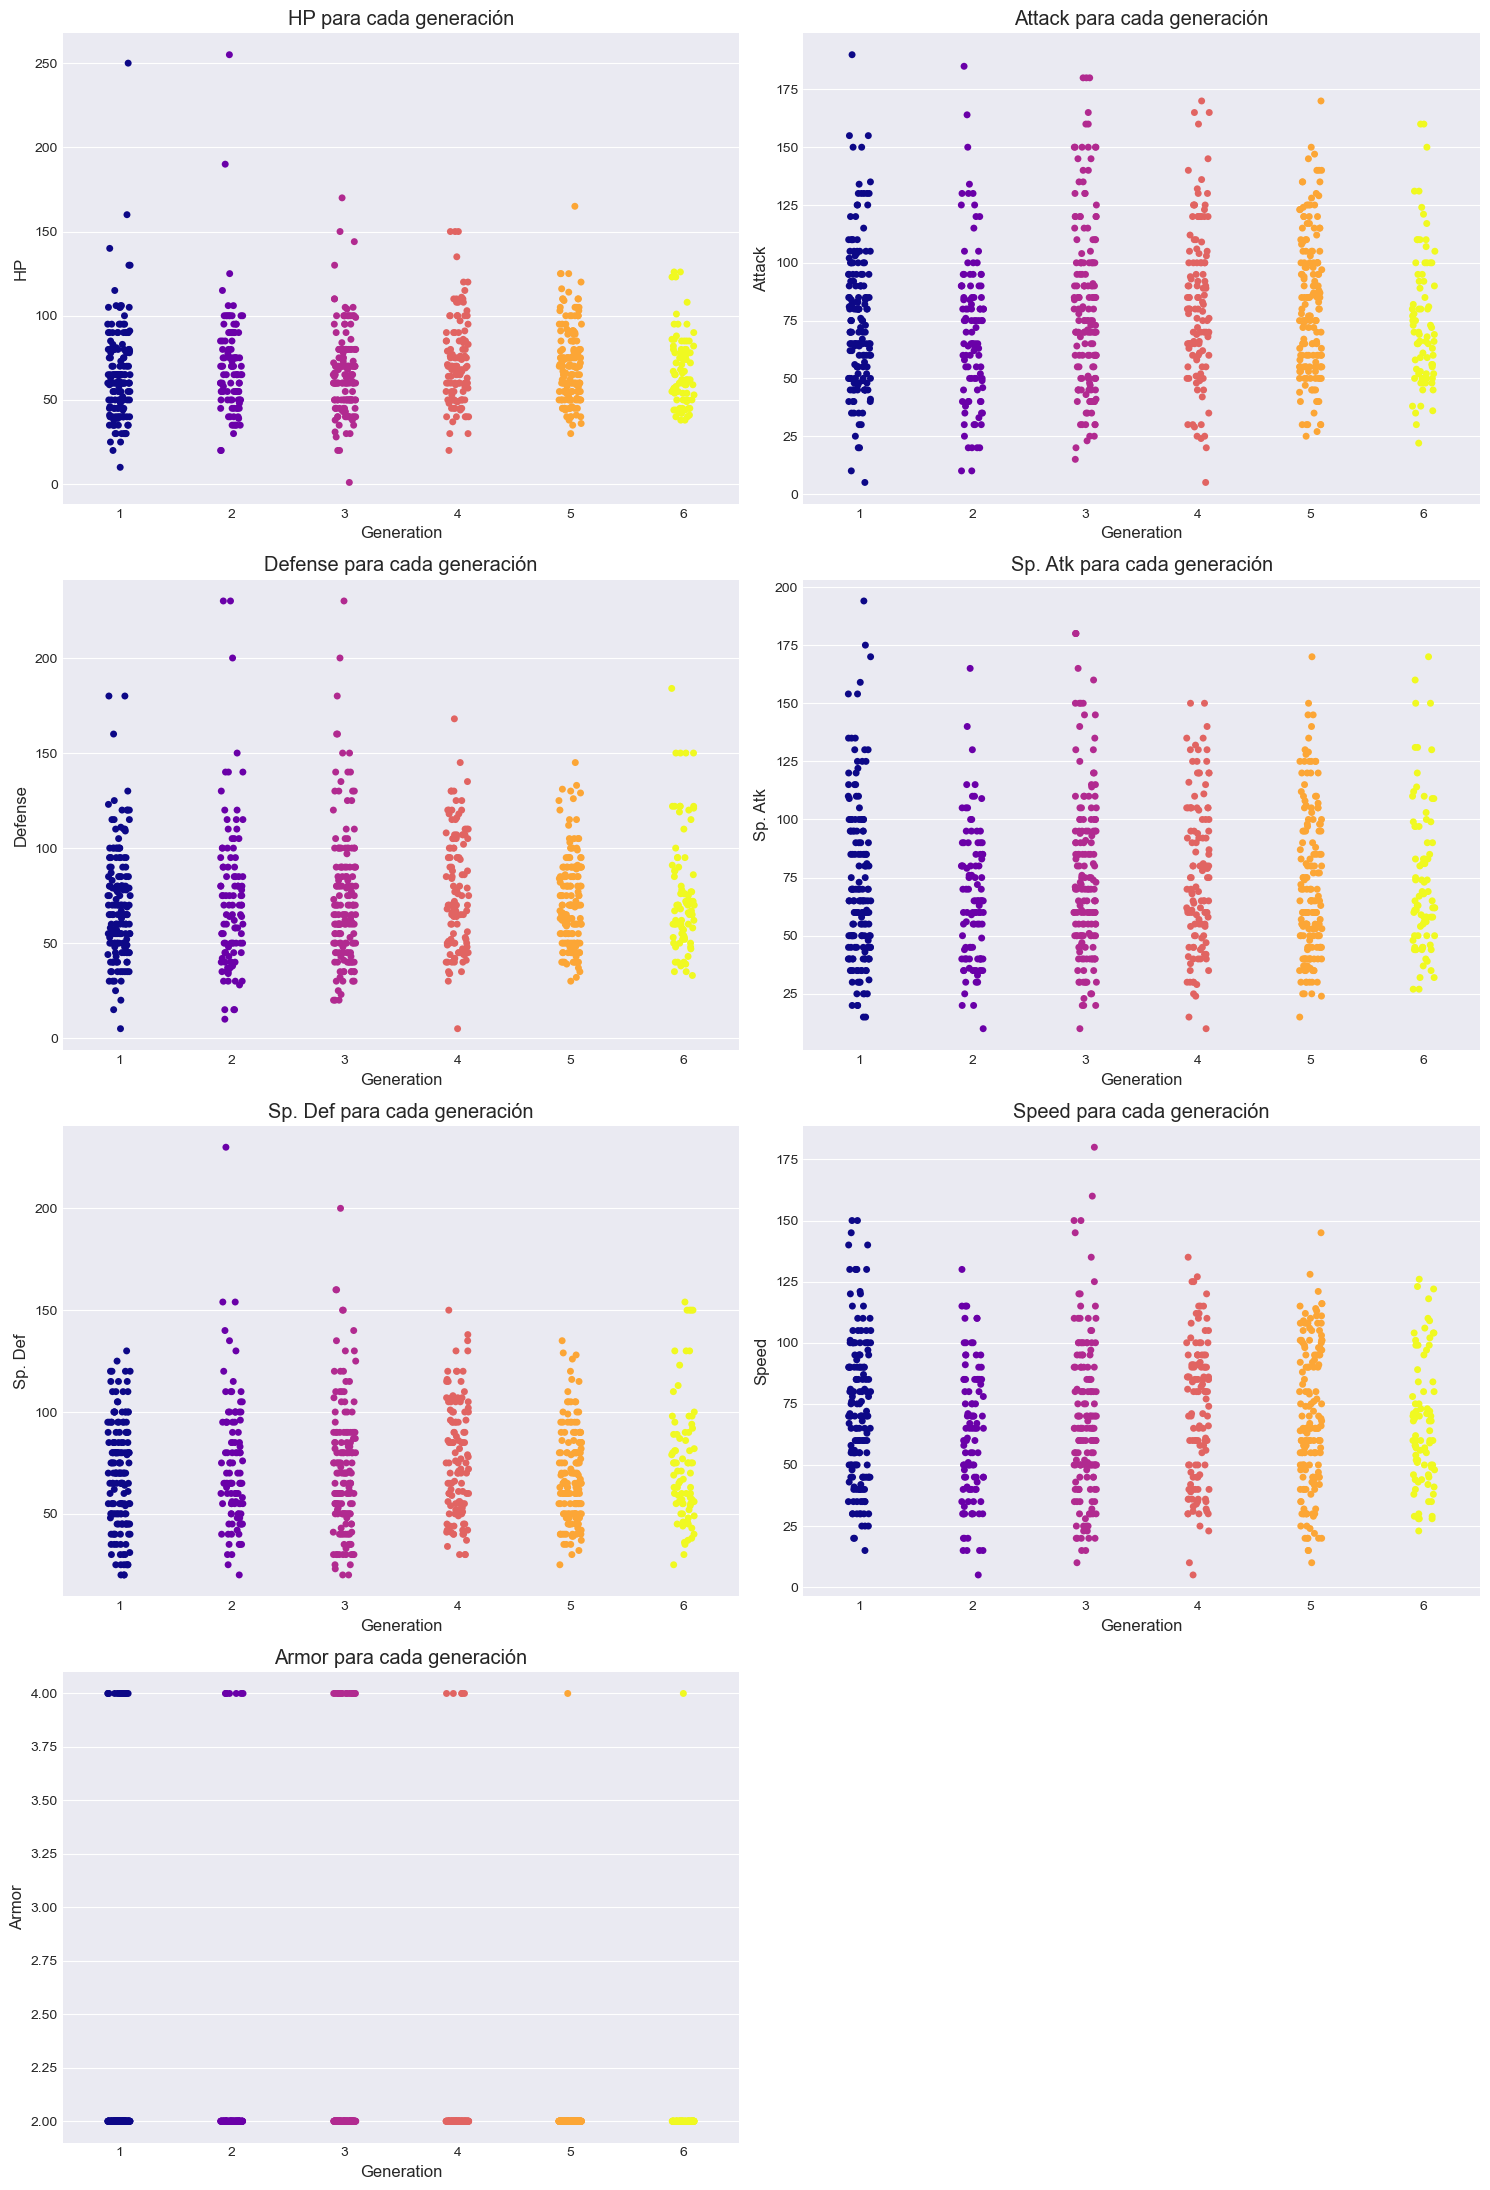

In [43]:
plt.figure(figsize=(15, 22))

for k, stat in enumerate(stats, start=1):
    plt.subplot(4, 2, k)
    sns.stripplot(
        data=pokemons,
        x='Generation',
        y=stat,
        hue='Generation',
        palette='plasma',
        legend=False,
        jitter=True
    )
    plt.title(f'{stat} para cada generación')

plt.tight_layout()
plt.show()

## 39. Estadísticas por generación con Boxplots

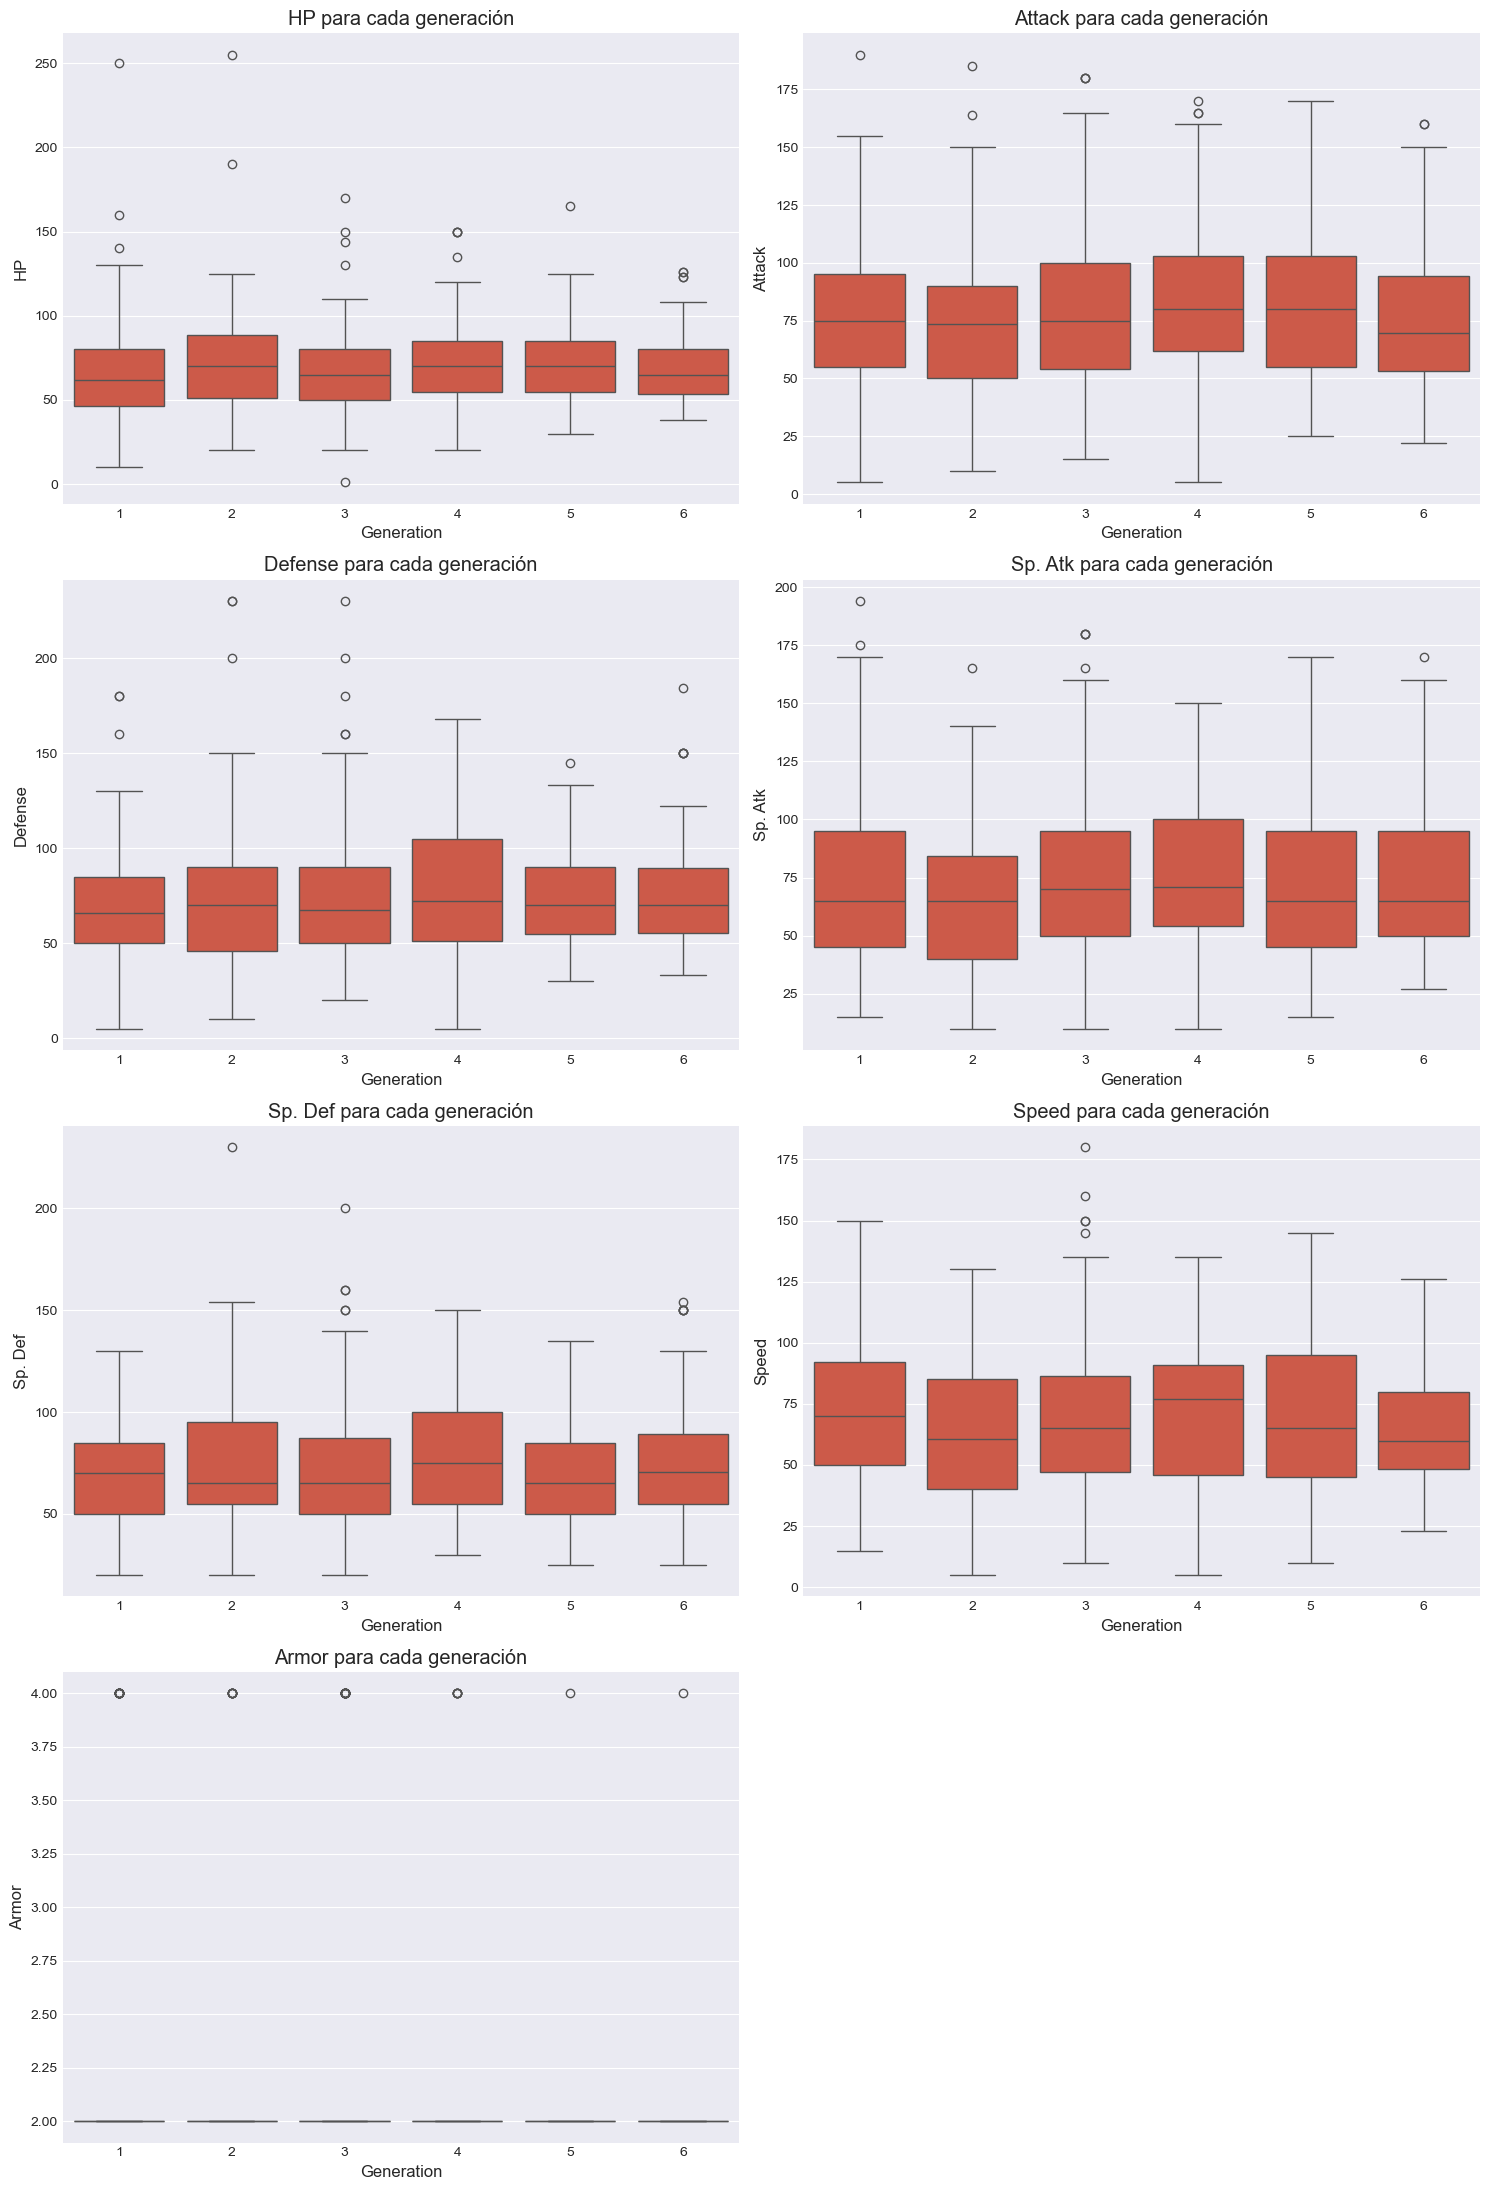

In [44]:
plt.figure(figsize=(15, 22))

for k, stat in enumerate(stats, start=1):
    plt.subplot(4, 2, k)
    sns.boxplot(data=pokemons, x='Generation', y=stat)
    plt.title(f'{stat} para cada generación')

plt.tight_layout()
plt.show()

## 40. Visualización interactiva con Bokeh

Se crea una gráfica de líneas para observar la suma de cada estadística por generación.

In [45]:
# Ejecuta esta celda únicamente si Bokeh está instalado en el entorno.
from bokeh.io import output_notebook, show
from bokeh.layouts import gridplot
from bokeh.plotting import figure

output_notebook()

plots = []
for stat in ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']:
    values = pokemons.groupby('Generation')[stat].sum()
    generations = values.index.tolist()

    plot = figure(width=400, height=230, title=f'{stat} por generación')
    plot.scatter(x=generations, y=values.values, size=6)
    plot.line(x=generations, y=values.values, line_width=2)
    plots.append(plot)

show(gridplot(plots, ncols=2))

Loading BokehJS ...

## 41. ¿Cuántos Pokémon legendarios hay en el dataset?

In [46]:
total_legendary = pokemons['Legendary'].sum()
print(f'Total de Pokémon legendarios: {total_legendary}')

Total de Pokémon legendarios: 65


## 42. Conteo de Pokémon legendarios por generación

In [47]:
legendary_by_generation = pokemons.groupby('Generation')['Legendary'].sum()
legendary_by_generation

Generation
1     6
2     5
3    18
4    13
5    15
6     8
Name: Legendary, dtype: int64

## 43. Gráfica de Pokémon legendarios por generación

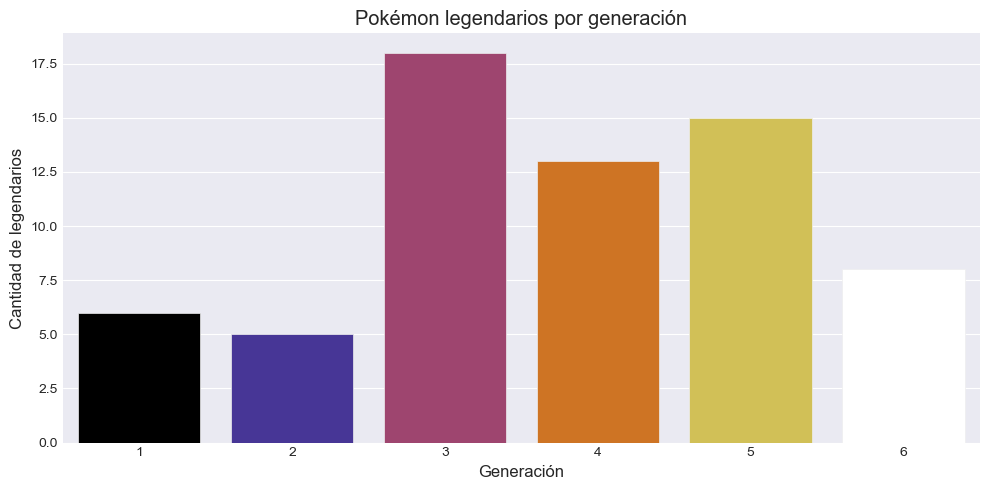

In [48]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=legendary_by_generation.index,
    y=legendary_by_generation.values,
    hue=legendary_by_generation.index,
    palette='CMRmap',
    legend=False
)
plt.title('Pokémon legendarios por generación')
plt.xlabel('Generación')
plt.ylabel('Cantidad de legendarios')
plt.tight_layout()
plt.show()

## 44. ¿Cuántos Pokémon legendarios hay por tipo?

In [49]:
legendary_by_type = pokemons.groupby(type_col)['Legendary'].sum().sort_values(ascending=False)
legendary_by_type

Type 1
Psychic     14
Dragon      12
Fire         5
Water        4
Ground       4
Electric     4
Steel        4
Rock         4
Grass        3
Dark         2
Ghost        2
Ice          2
Normal       2
Flying       2
Fairy        1
Poison       0
Fighting     0
Bug          0
Name: Legendary, dtype: int64

## 45. Gráfica de Pokémon legendarios por tipo

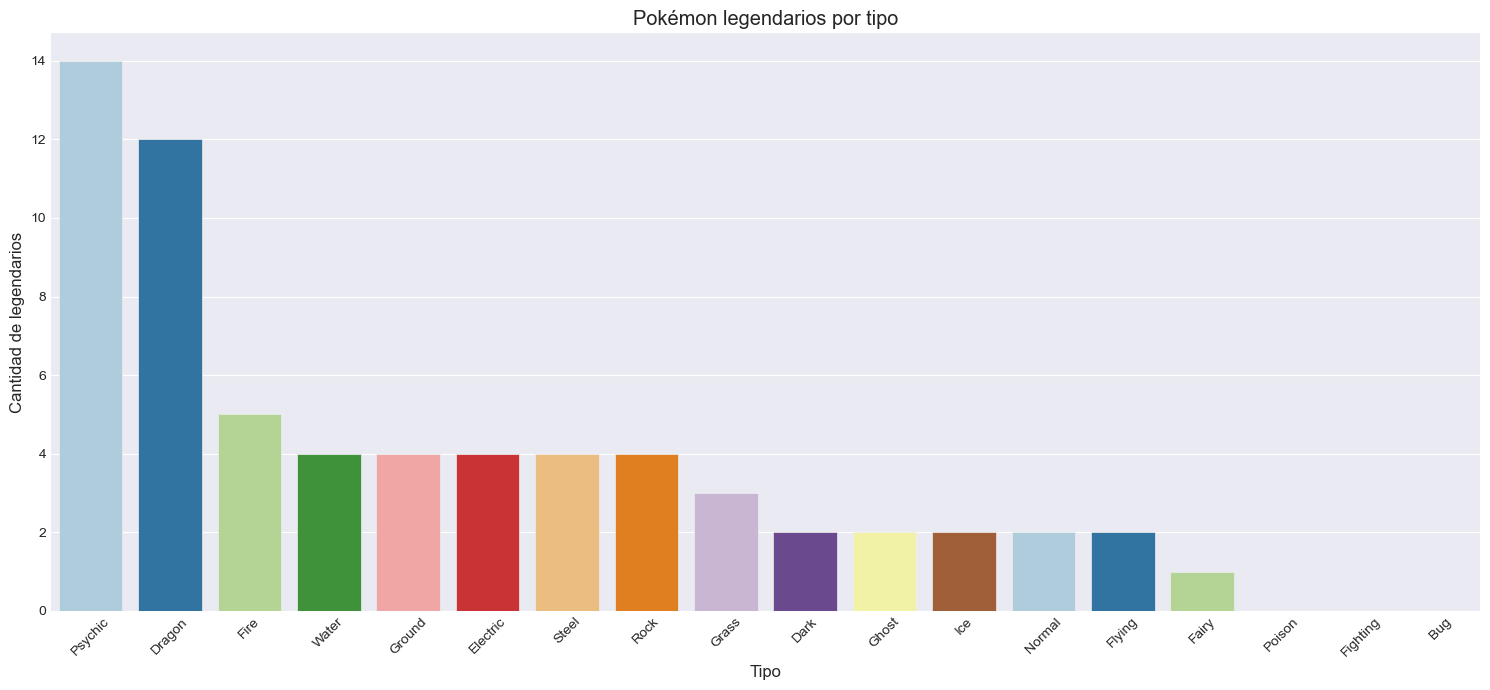

In [50]:
plt.figure(figsize=(15, 7))
sns.barplot(
    x=legendary_by_type.index,
    y=legendary_by_type.values,
    hue=legendary_by_type.index,
    palette='Paired',
    legend=False
)
plt.title('Pokémon legendarios por tipo')
plt.xlabel('Tipo')
plt.ylabel('Cantidad de legendarios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 46. Comparación de estadísticas de Pokémon legendarios

Se comparan las estadísticas de Pokémon legendarios y no legendarios para cada tipo.

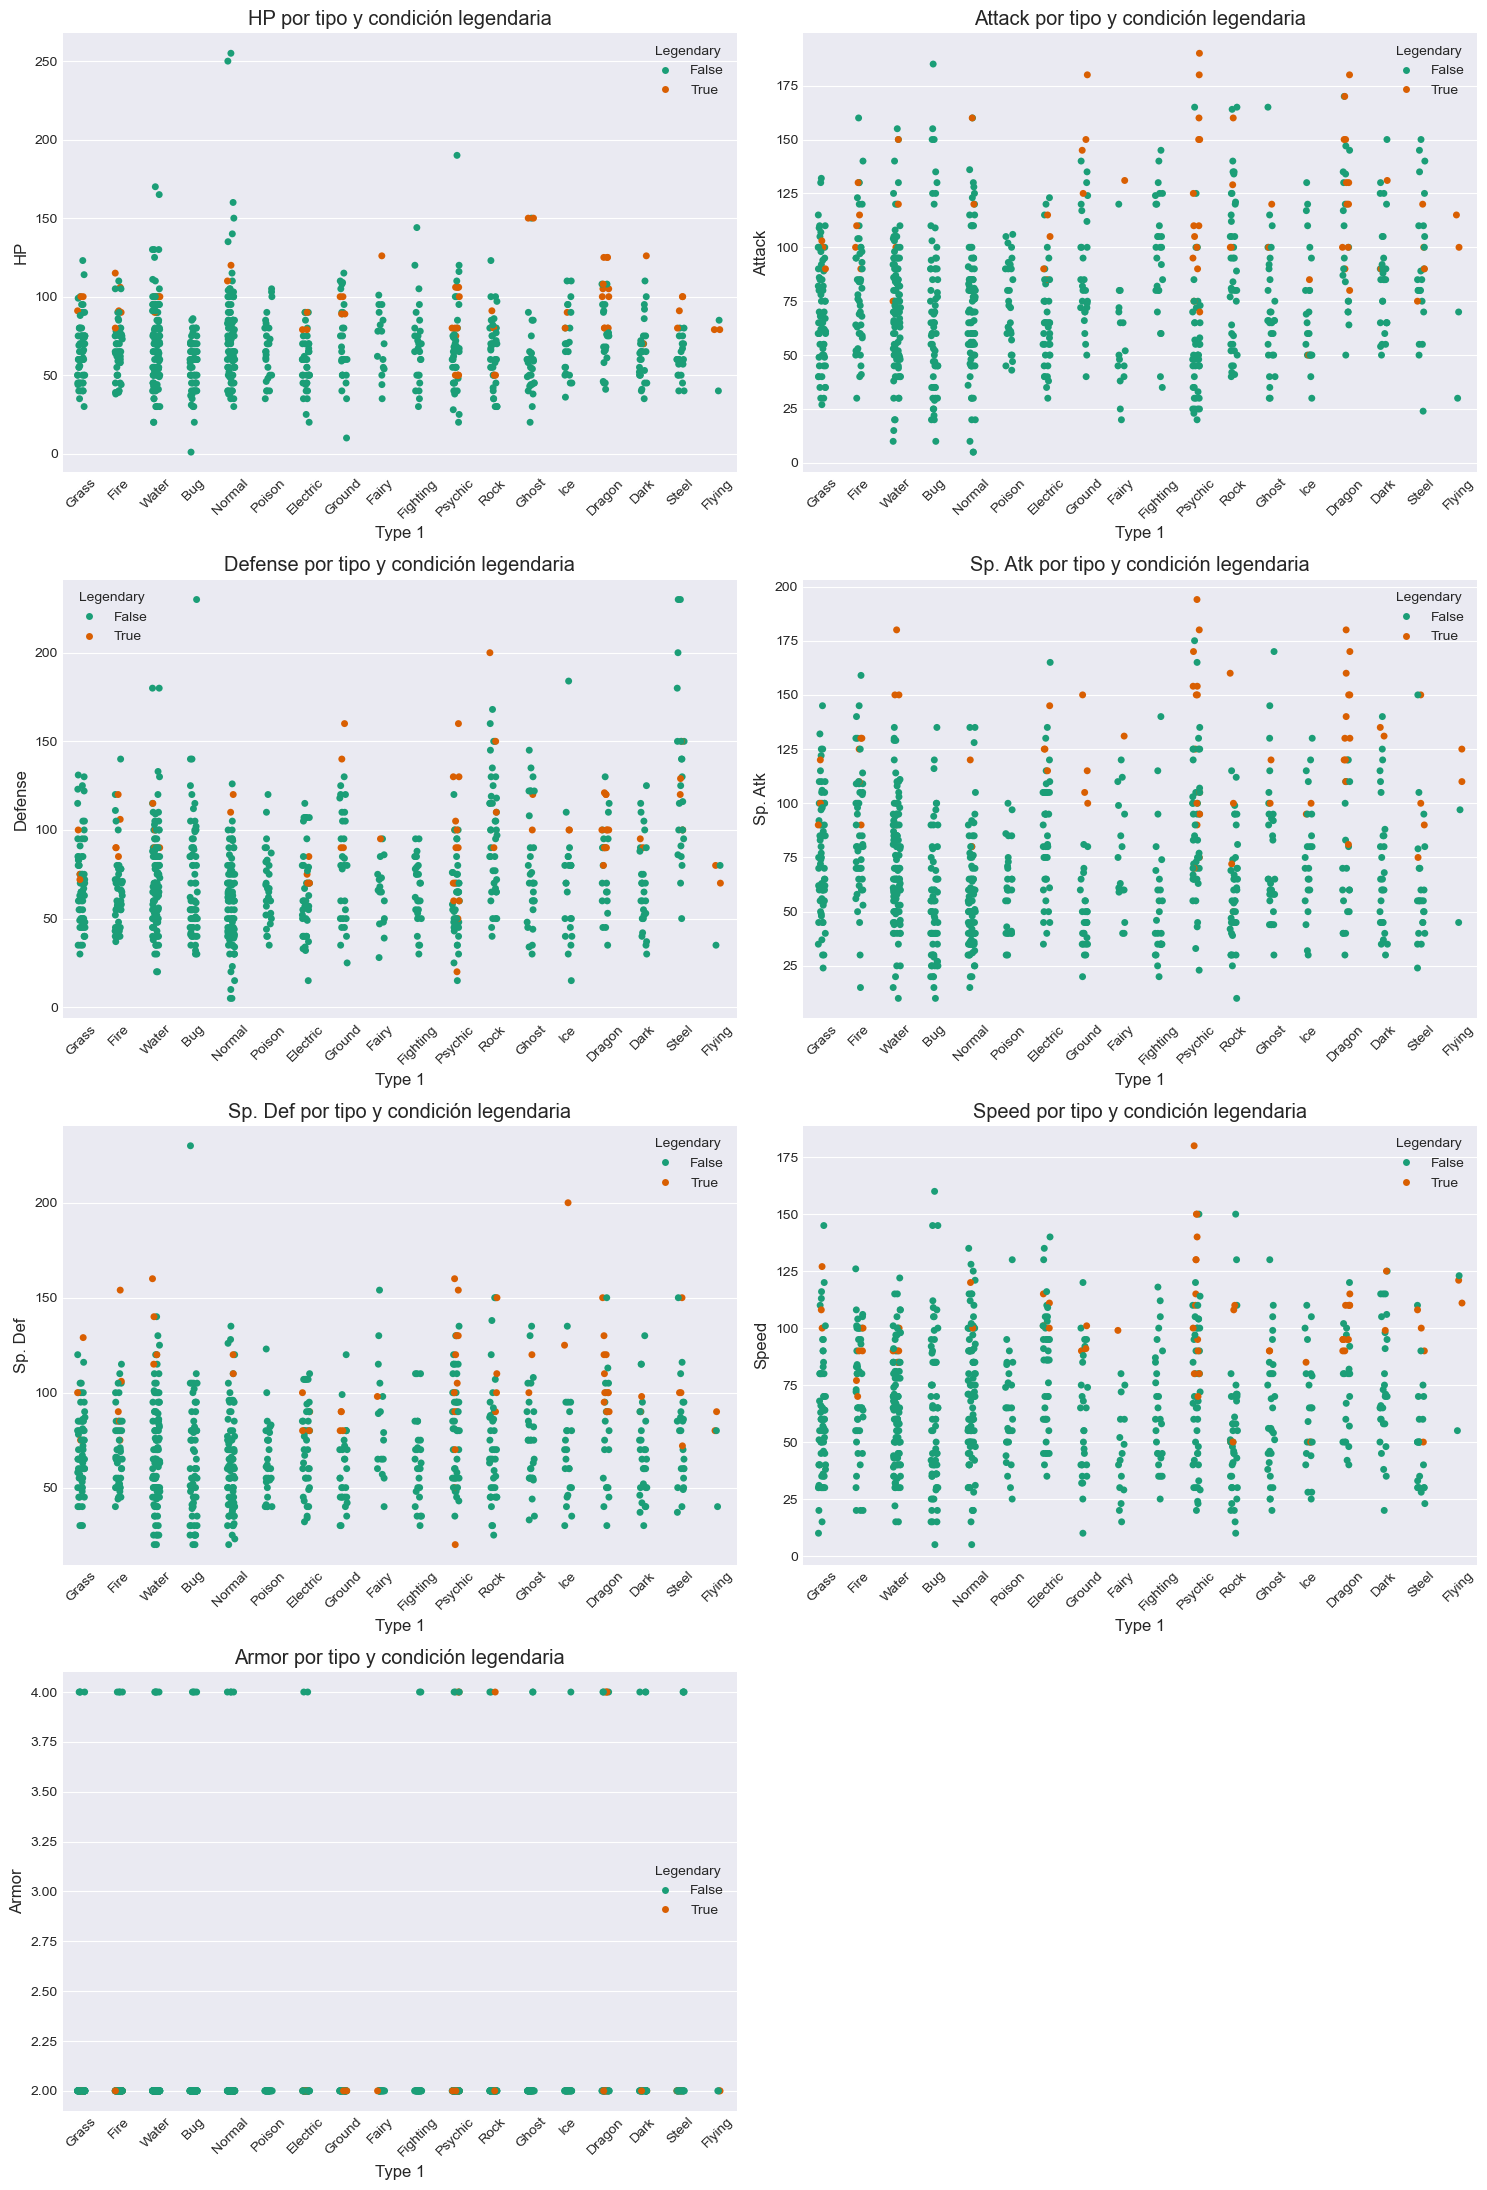

In [51]:
plt.figure(figsize=(15, 22))

for k, stat in enumerate(stats, start=1):
    plt.subplot(4, 2, k)
    sns.stripplot(
        data=pokemons,
        x=type_col,
        y=stat,
        hue='Legendary',
        palette='Dark2',
        jitter=True
    )
    plt.title(f'{stat} por tipo y condición legendaria')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 47. Estadísticas de cada tipo de Pokémon

Los datos se preparan en formato largo para observar las estadísticas de los Pokémon por tipo.

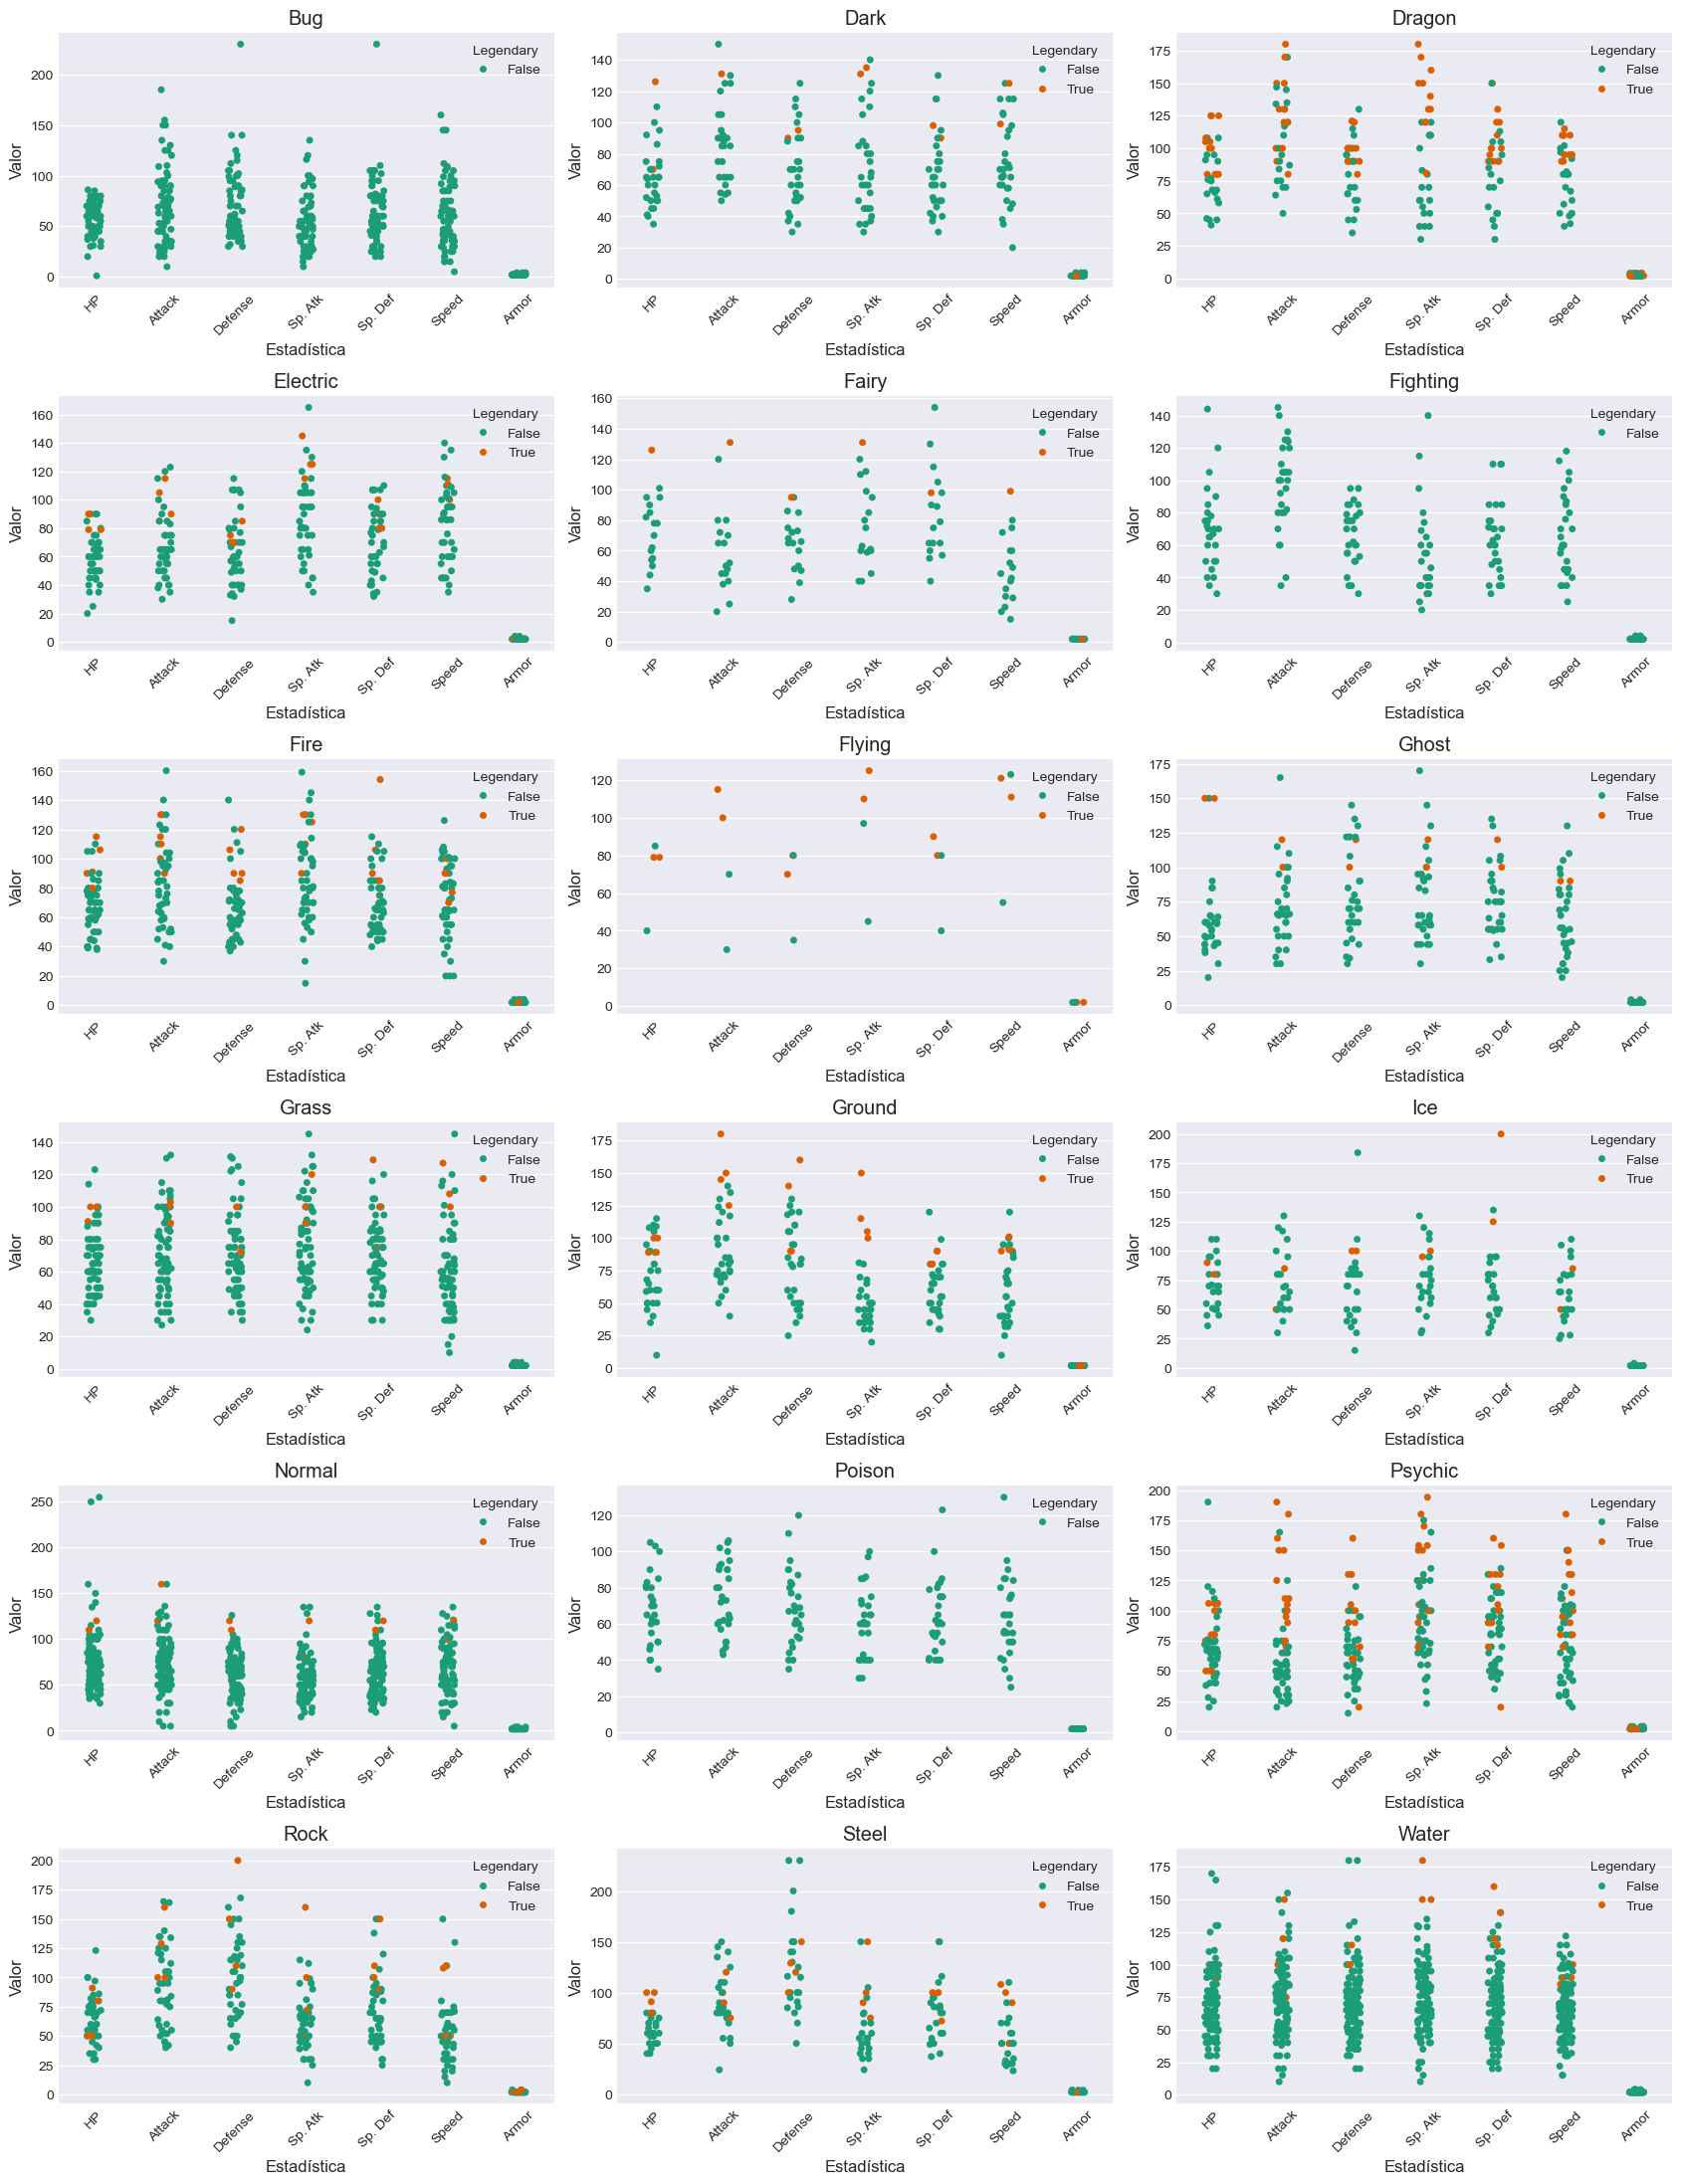

In [52]:
pok_melt = pd.melt(
    pokemons,
    id_vars=['Name_Corrected', type_col, 'Legendary'],
    value_vars=stats,
    var_name='Estadística',
    value_name='Valor'
)

plt.figure(figsize=(17, 25))

for k, pokemon_type in enumerate(list_types, start=1):
    plt.subplot(7, 3, k)
    type_melted = pok_melt[pok_melt[type_col] == pokemon_type]
    sns.stripplot(
        data=type_melted,
        x='Estadística',
        y='Valor',
        hue='Legendary',
        palette='Dark2',
        jitter=True
    )
    plt.title(pokemon_type)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 48. Pokémon legendarios con estadísticas superiores al promedio

Se calcula cuántos Pokémon legendarios superan la media general de cada estadística.

In [53]:
legendary = pokemons[pokemons['Legendary'] == True]
total_legendary = len(legendary)

for stat in stats:
    above_average = len(legendary[legendary[stat] > pokemons[stat].mean()])
    percentage = round((above_average / total_legendary) * 100, 2) if total_legendary else 0
    print(f'{stat}: {above_average} legendarios arriba del promedio ({percentage}%)')

HP: 59 legendarios arriba del promedio (90.77%)
Attack: 60 legendarios arriba del promedio (92.31%)
Defense: 55 legendarios arriba del promedio (84.62%)
Sp. Atk: 62 legendarios arriba del promedio (95.38%)
Sp. Def: 62 legendarios arriba del promedio (95.38%)
Speed: 61 legendarios arriba del promedio (93.85%)
Armor: 6 legendarios arriba del promedio (9.23%)


## 49. Mapa de calor de correlación

El mapa de calor muestra las relaciones lineales entre las variables numéricas del dataset.

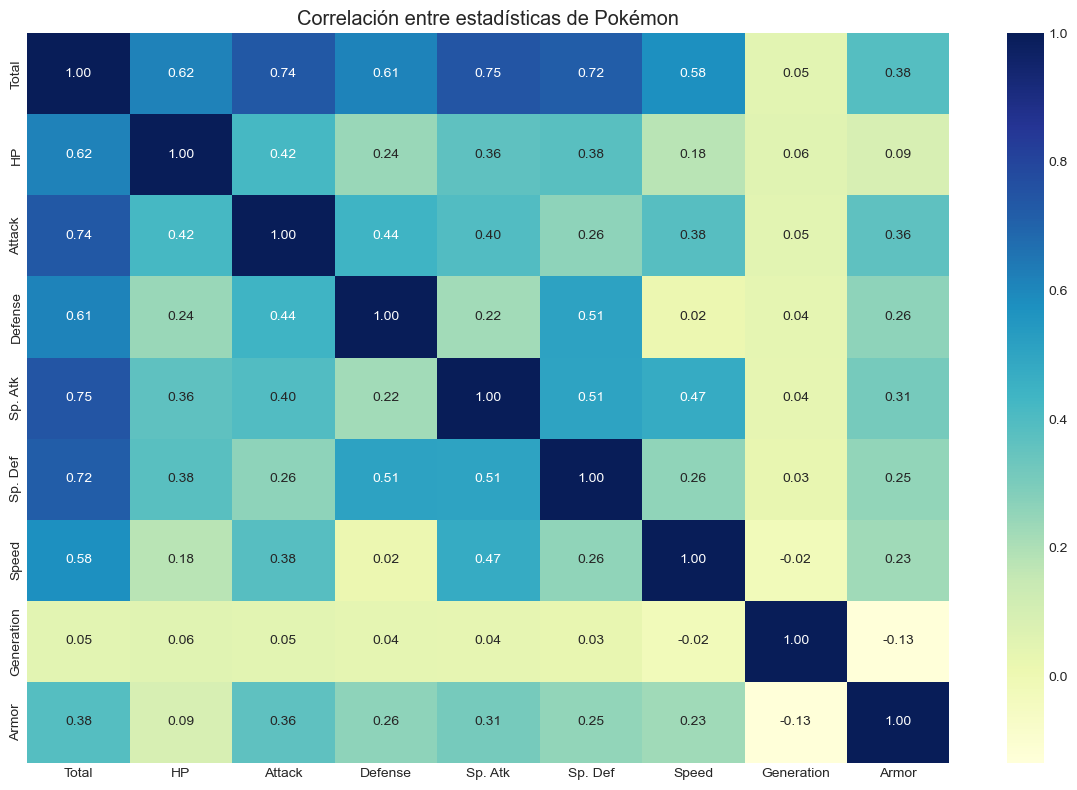

In [54]:
correlation_columns = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', evolution_col]

plt.figure(figsize=(12, 8))
sns.heatmap(pokemons[correlation_columns].corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlación entre estadísticas de Pokémon')
plt.tight_layout()
plt.show()

## 50. Pairplot de estadísticas de Pokémon

Esta visualización permite comparar pares de estadísticas y observar su distribución.

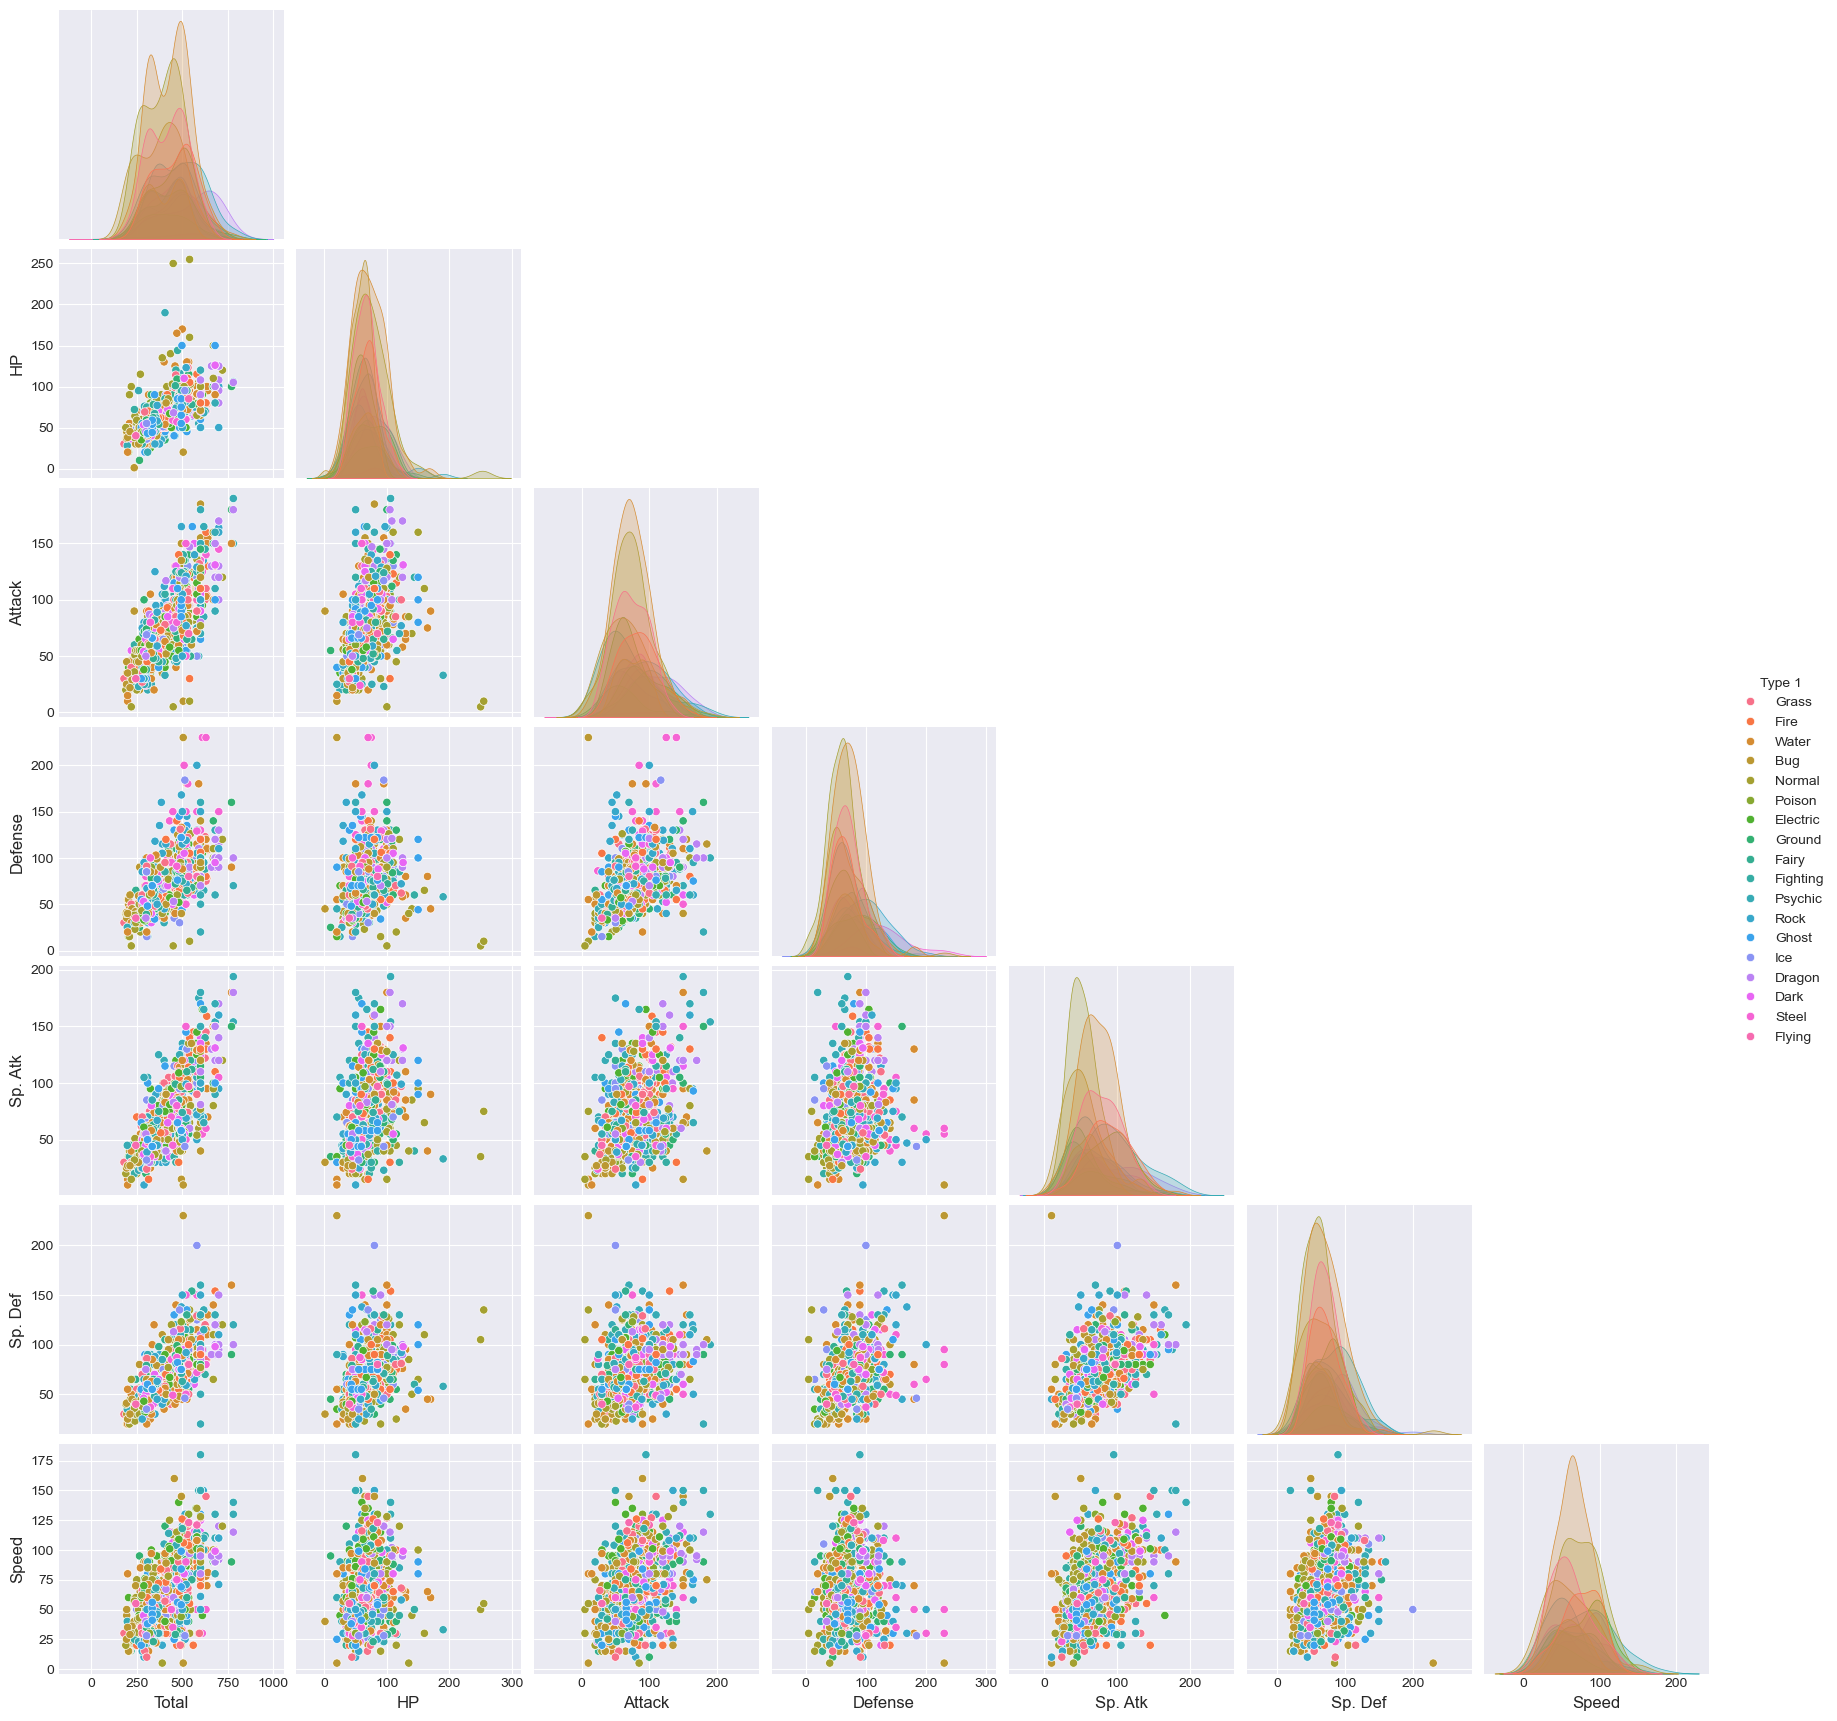

In [55]:
pairplot_columns = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', type_col]
sns.pairplot(pokemons[pairplot_columns], hue=type_col, corner=True)
plt.show()

## Conclusión

El análisis exploratorio permitió identificar la distribución de los Pokémon por tipo y generación, comparar sus estadísticas principales y reconocer diferencias entre Pokémon legendarios y no legendarios. Las visualizaciones facilitan la detección de patrones, valores extremos y relaciones entre variables, lo cual es útil para preparar los datos antes de aplicar técnicas de análisis más avanzadas.